# Door Condition Monitoring: Anomaly Detection Pipeline



## Executive summary

Railway doors are instrumented with sensors that record each open and close cycle.
This notebook builds a pipeline that takes that raw sensor data and flags whether a
door operation is normal or faulty, and if faulty, which of ten fault types it most
resembles.

**The data.** Thousands of door cycles stored as nested JSON files, grouped into
folders by condition (normal plus ten fault types). Each cycle contains motor
current, position and speed traces, along with timing and switch signals.

**The approach.** We extract and clean the data, reduce each cycle to a set of
descriptive features with feature engineering, and train a model to classify each cycle. Open and close operations are
handled by separate models, as they behave very differently.

**Summary of Findings:**
- The model classifies faults well (macro-F1 score around 0.92 to 0.95)
- A few fault types that produce only subtle, localised changes are harder to detect.
- The provided data has an important limitation: each fault was recorded at a
  different time from normal operation, so part of the model's apparent skill could
  reflect *when* a cycle was recorded rather than *how the door behaved*. This is tested and reported as a limitation.`

In [5]:
import json
import os
import glob
import ast

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import matplotlib as mpl
mpl.rcParams['figure.dpi'] = 80  

## Data Extraction

### Sample folder reading

In [6]:
folder_path_0 = './'
folder_names = os.listdir(folder_path_0)

In [7]:
# there appears to be multiple JSON records in each JSON file, and the data types look very similar. 
# The folder name suggests whether there is an anomaly or not, so start with NormalData to examine what it looks like

records = []

file_names = os.listdir('./NormalData')

for file in file_names:

    with open(f'./NormalData/{file}', 'r', encoding='utf-8') as f:
        decoder = json.JSONDecoder()
        text = f.read()

    pos = 0
    while pos < len(text):
        # Skip whitespace between JSON objects
        while pos < len(text) and text[pos].isspace():
            pos += 1

        if pos >= len(text):
            break

        # decode JSON object
        obj, pos = decoder.raw_decode(text, pos)

        records.append(obj)

    test_df = pd.DataFrame(records)


In [8]:
test_df.head(5)

,ActionTime,CloseSwitch,CloseSwitchActionAngle,DoorEnabled,FullyLock,FullyOpen,HappenTime,LastAngle,LockSwitch,LockSwitchActionAngle,MaxCurrent,MotorCurrent,MotorPosition,MotorSpeed,ZeroSpeed,isopendoor
0,570,"[{'offset': 0, 'value': 101}, {'offset': 270, ...",170,"[{'offset': 0, 'value': 100}, {'offset': 270, ...","[{'offset': 0, 'value': 100}, {'offset': 270, ...","[{'offset': 0, 'value': 101}, {'offset': 270, ...",1684223571255,343,"[{'offset': 0, 'value': 100}, {'offset': 270, ...",105,6060,"[62, 66, 64, 74, 75, 62, 54, 60, 56, 55, 53, 6...","[344, 339, 332, 325, 318, 313, 306, 300, 294, ...","[-641, -663, -651, -676, -708, -666, -620, -64...","[{'offset': 0, 'value': 100}, {'offset': 270, ...",1
1,3240,"[{'offset': -250, 'value': 101}, {'offset': -4...",212,"[{'offset': -250, 'value': 100}, {'offset': -4...","[{'offset': -250, 'value': 100}, {'offset': -4...","[{'offset': -250, 'value': 100}, {'offset': -4...",1684223598887,3860,"[{'offset': -250, 'value': 100}, {'offset': -4...",146,1960,"[148, 213, 195, 170, 164, 134, 131, 152, 169, ...","[103, 108, 115, 125, 135, 151, 158, 168, 180, ...","[101, 233, 896, 1165, 1246, 1412, 1445, 1384, ...","[{'offset': -250, 'value': 100}, {'offset': -4...",0
2,3290,"[{'offset': -3128, 'value': 101}, {'offset': -...",170,"[{'offset': -3128, 'value': 100}, {'offset': -...","[{'offset': -3128, 'value': 100}, {'offset': -...","[{'offset': -3128, 'value': 101}, {'offset': -...",1699921198611,3861,"[{'offset': -3128, 'value': 100}, {'offset': -...",106,6230,"[34, 28, -40, -47, -59, -12, -27, -21, 6, -52,...","[3862, 3856, 3851, 3844, 3838, 3829, 3822, 381...","[99, -29, -542, -594, -659, -771, -863, -815, ...","[{'offset': -3128, 'value': 100}, {'offset': -...",1
3,3250,"[{'offset': -291, 'value': 101}, {'offset': -9...",212,"[{'offset': -291, 'value': 100}, {'offset': -9...","[{'offset': -291, 'value': 100}, {'offset': -9...","[{'offset': -291, 'value': 100}, {'offset': -9...",1699921207041,3858,"[{'offset': -291, 'value': 100}, {'offset': -9...",147,1930,"[196, 219, 181, 153, 161, 134, 135, 158, 168, ...","[105, 111, 120, 130, 141, 153, 163, 173, 183, ...","[108, 479, 1069, 1215, 1273, 1398, 1429, 1346,...","[{'offset': -291, 'value': 100}, {'offset': -9...",0
4,3290,"[{'offset': -3148, 'value': 101}, {'offset': -...",171,"[{'offset': -3148, 'value': 100}, {'offset': -...","[{'offset': -3148, 'value': 100}, {'offset': -...","[{'offset': -3148, 'value': 101}, {'offset': -...",1699921217520,3857,"[{'offset': -3148, 'value': 100}, {'offset': -...",106,6200,"[23, -43, -39, -41, -23, -9, 3, -40, -27, -62,...","[3858, 3853, 3846, 3839, 3832, 3824, 3817, 380...","[86, -417, -581, -657, -715, -818, -862, -818,...","[{'offset': -3148, 'value': 100}, {'offset': -...",1


In [9]:
# There are 3 types of column data here: Scalar/Single value columns, waveform columns in array formats and digital/switch columns that have two possible values, 100 and 101.

SCALAR_COLS = [
    "ActionTime", "CloseSwitchActionAngle", "HappenTime", "LastAngle",
    "LockSwitchActionAngle", "MaxCurrent", "isopendoor",
]

WAVEFORM_COLS = ["MotorCurrent", "MotorPosition", "MotorSpeed"]

DIGITAL_COLS = [
    "CloseSwitch", "DoorEnabled", "FullyLock", "FullyOpen", "LockSwitch", "ZeroSpeed",
]

def parse_waveform(value):
    # convert the python list into a numpy array as a preprocessing step
    if isinstance(value, str):
        value = ast.literal_eval(value)
    return np.asarray(value, dtype=float)


def parse_digital(value):
    # list of dictionaries with two of the same keys for each value
    # Convert the digital columns from a dictionary to a list of tuples that can be plot on a graph later on
    if isinstance(value, str):
        value = ast.literal_eval(value)
    return [(d["offset"], d["value"]) for d in value]

### Read full dataset

In [10]:
# Write helper functions to convert all the JSON files into a single dataframe

def read_json_records(path):
    # Read a file holding multiple concatenated JSON objects into a list.
    decoder = json.JSONDecoder()
    with open(path, "r", encoding="utf-8") as f:
        text = f.read()

    records = []
    pos, n = 0, len(text)
    while pos < n:
        while pos < n and text[pos].isspace():   # skip whitespace between objects
            pos += 1
        if pos >= n:
            break
        obj, pos = decoder.raw_decode(text, pos)
        records.append(obj)
    return records


def load_dataset_from_tree(root):
    # concatenate the list of JSON objects from different folders then convert into a dataframe
    frames = []
    for folder in sorted(glob.glob(os.path.join(root, "*"))):
        if not os.path.isdir(folder):
            continue
        label = os.path.basename(folder)
        for fp in sorted(glob.glob(os.path.join(folder, "*.json"))):
            records = read_json_records(fp)
            if not records:
                continue
            part = pd.DataFrame(records)
            part["label"] = label                      # fault type presumed from folder name
            part["source_file"] = os.path.basename(fp)  # keep source file name
            frames.append(part)

    if not frames:
        raise FileNotFoundError(f"No JSON files found under {root!r}")

    data = pd.concat(frames, ignore_index=True)

    data["is_normal"] = data["label"].eq("NormalData") # The NormalData folder is assumed to be the normal label, everything else is an anomaly/not normal label
    
    return data

In [11]:
# check for Nulls
df = load_dataset_from_tree("./")
print(len(df))
df.isna().sum()

9534


ActionTime                0
CloseSwitch               1
CloseSwitchActionAngle    1
DoorEnabled               1
FullyLock                 1
FullyOpen                 1
HappenTime                0
LastAngle                 0
LockSwitch                1
LockSwitchActionAngle     3
MaxCurrent                0
MotorCurrent              0
MotorPosition             0
MotorSpeed                0
ZeroSpeed                 1
isopendoor                0
label                     0
source_file               0
is_normal                 0
dtype: int64

In [12]:
# Small number of NAs compared to overall dataset, I will choose to drop them
df = df.dropna()
df.to_csv('a.csv')

In [13]:
for col in WAVEFORM_COLS:
    df[col] = df[col].apply(parse_waveform)
for col in DIGITAL_COLS:
    df[col] = df[col].apply(parse_digital)

In [14]:
# to plot the waveform columns as a time series, ideally in each row all waveform columns need to have the same length
# Run a check on the length

lengths = df[WAVEFORM_COLS].apply(lambda x: x.map(len))
same = lengths.nunique(axis=1) == 1 # check length along rows

print("all rows consistent:", same.all())
if not same.all():
    print("rows where the three lengths differ:", df.index[~same].tolist())
    print(lengths[~same])

all rows consistent: True


In [15]:
df["n_samples"] = df["MotorCurrent"].apply(len)   # Since all waveforms have the same length within each row, cycle length = duration proxy/x-axis for timeseries

In [16]:
df['label'].value_counts()
# there is a class imabalance which should be noted when running a model later

label
BufferHeadWear                     2383
NormalData                         1460
FullStrokeResistanceAnomaly        1081
LocalResistanceAnomaly             1079
PressureRollerTooTight              794
LowerStopPinInterference            789
LowerStopPinLateralInterference     724
V-ShapeDimensionAnomaly             544
UpperSlideTrackAnomaly              439
CenteringDimensionAnomaly           148
LowerArmRollerNotRotating            90
Name: count, dtype: int64

In [17]:
df.head()

,ActionTime,CloseSwitch,CloseSwitchActionAngle,DoorEnabled,FullyLock,FullyOpen,HappenTime,LastAngle,LockSwitch,LockSwitchActionAngle,MaxCurrent,MotorCurrent,MotorPosition,MotorSpeed,ZeroSpeed,isopendoor,label,source_file,is_normal,n_samples
0,3370,"[(-290, 101), (-80, 101), (0, 101), (41, 101),...",212.0,"[(-290, 100), (-80, 100), (0, 100), (41, 100),...","[(-290, 100), (-80, 100), (0, 100), (41, 100),...","[(-290, 100), (-80, 101), (0, 101), (41, 101),...",1695879257804,3891,"[(-290, 100), (-80, 100), (0, 100), (41, 100),...",149.0,1900,"[200.0, 187.0, 153.0, 153.0, 136.0, 142.0, 160...","[110.0, 118.0, 127.0, 137.0, 149.0, 159.0, 171...","[114.0, 1020.0, 1227.0, 1281.0, 1418.0, 1395.0...","[(-290, 100), (-80, 100), (0, 100), (41, 100),...",0,BufferHeadWear,0928.json,False,424
1,3320,"[(-3117, 101), (-2917, 101), (-2877, 101), (-2...",173.0,"[(-3117, 100), (-2917, 100), (-2877, 100), (-2...","[(-3117, 100), (-2917, 100), (-2877, 100), (-2...","[(-3117, 101), (-2917, 101), (-2877, 101), (-2...",1695879434343,3894,"[(-3117, 100), (-2917, 100), (-2877, 100), (-2...",108.0,6640,"[7.0, -8.0, -55.0, -31.0, -47.0, 12.0, -6.0, -...","[3897.0, 3891.0, 3885.0, 3879.0, 3872.0, 3863....","[92.0, -292.0, -548.0, -634.0, -701.0, -814.0,...","[(-3117, 100), (-2917, 100), (-2877, 100), (-2...",1,BufferHeadWear,0928.json,False,448
2,3270,"[(-261, 101), (-60, 101), (41, 101), (91, 101)...",212.0,"[(-261, 100), (-60, 100), (41, 100), (91, 100)...","[(-261, 100), (-60, 100), (41, 100), (91, 100)...","[(-261, 100), (-60, 101), (41, 101), (91, 101)...",1695879443707,3891,"[(-261, 100), (-60, 100), (41, 100), (91, 100)...",149.0,1990,"[193.0, 174.0, 165.0, 159.0, 135.0, 143.0, 161...","[110.0, 118.0, 129.0, 139.0, 151.0, 161.0, 171...","[258.0, 1053.0, 1231.0, 1274.0, 1404.0, 1412.0...","[(-261, 100), (-60, 100), (41, 100), (91, 100)...",0,BufferHeadWear,0928.json,False,424
3,3330,"[(-3158, 101), (-2957, 101), (-2917, 101), (-2...",173.0,"[(-3158, 100), (-2957, 100), (-2917, 100), (-2...","[(-3158, 100), (-2957, 100), (-2917, 100), (-2...","[(-3158, 101), (-2957, 101), (-2917, 101), (-2...",1695879460439,3896,"[(-3158, 100), (-2957, 100), (-2917, 100), (-2...",108.0,6750,"[37.0, 10.0, -30.0, -41.0, -20.0, -32.0, -10.0...","[3899.0, 3892.0, 3887.0, 3882.0, 3875.0, 3868....","[97.0, -22.0, -544.0, -546.0, -633.0, -714.0, ...","[(-3158, 100), (-2957, 100), (-2917, 100), (-2...",1,BufferHeadWear,0928.json,False,448
4,3280,"[(-271, 101), (-70, 101), (50, 101), (120, 101...",212.0,"[(-271, 100), (-70, 100), (50, 100), (120, 100...","[(-271, 100), (-70, 100), (50, 100), (120, 100...","[(-271, 100), (-70, 101), (50, 101), (120, 101...",1695879468911,3895,"[(-271, 100), (-70, 100), (50, 100), (120, 100...",147.0,1950,"[203.0, 204.0, 161.0, 163.0, 165.0, 140.0, 146...","[106.0, 113.0, 122.0, 132.0, 142.0, 153.0, 164...","[101.0, 400.0, 1137.0, 1248.0, 1308.0, 1413.0,...","[(-271, 100), (-70, 100), (50, 100), (120, 100...",0,BufferHeadWear,0928.json,False,425


Looking at the data, it can be concluded that each row is a door cycle, either opening or closing based on the isopendoor label. The data has either normal operation or anomalous/faulty operation, which is indicated in the folder names and saved as the label in the dataframe. Each door cycle has data that comes in various formats: scalar values, array values (magnitudes on a waveform) and arrays with tuples in them. At first glance they seem to fall neatly into these 3 different buckets and will be treated as the different features that can be used to show if a door operation is anomalous

## Visualizations 

### Scalar Data

In [18]:
# get basic stats for scalar columns
# Examine normal operations first
normal_df = df[df["is_normal"]]
normal_df[SCALAR_COLS].describe()

,ActionTime,CloseSwitchActionAngle,HappenTime,LastAngle,LockSwitchActionAngle,MaxCurrent,isopendoor
count,1460.000000,1460.000000,1.460000e+03,1460.000000,1460.000000,1460.000000,1460.000000
mean,3276.616438,191.689726,1.699912e+12,3855.655479,127.450685,4101.952055,0.500000
std,73.254349,20.492906,5.813139e+08,92.013438,19.401699,2215.948074,0.500171
min,570.000000,170.000000,1.684224e+12,343.000000,105.000000,1750.000000,0.000000
25%,3260.000000,171.000000,1.699926e+12,3857.000000,108.000000,1880.000000,0.000000
50%,3280.000000,192.000000,1.699931e+12,3858.000000,128.000000,4000.000000,0.500000
75%,3300.000000,212.000000,1.699942e+12,3860.000000,147.000000,6320.000000,1.000000
max,3310.000000,214.000000,1.699947e+12,3861.000000,149.000000,6550.000000,1.000000


There seem to be a few anomalies here, so will have to remove them. Plot histograms to check distributions

#### Outlier Cleaning

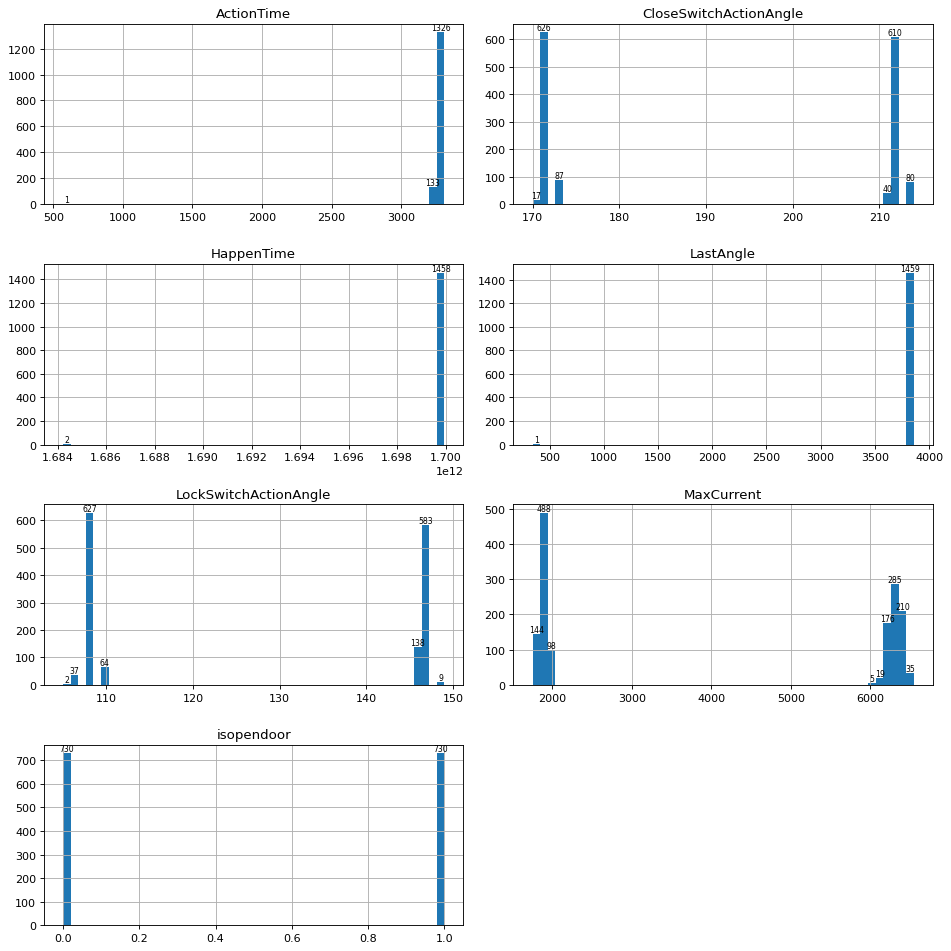

In [19]:
axes = normal_df[SCALAR_COLS].hist(bins=50, layout=(4, 2), figsize=(12, 12))
for ax in axes.ravel():
    for p in ax.patches:
        h = p.get_height()
        if h > 0:                                  # skip empty bins
            ax.annotate(int(h),
                        (p.get_x() + p.get_width() / 2, h),
                        ha="center", va="bottom", fontsize=7)
plt.tight_layout()
plt.show()

Looking at the statistics and plots it looks like there are two distributions in many of the scalar columns, and it's very likely due to the isopendoor binary variable. The first step will be to split the dataset by that variable and examine the distributions based on that.

In [20]:
# Split data into open and closed door
normal_df_isopen = normal_df[normal_df['isopendoor']==1]
normal_df_isclosed = normal_df[normal_df['isopendoor']==0]

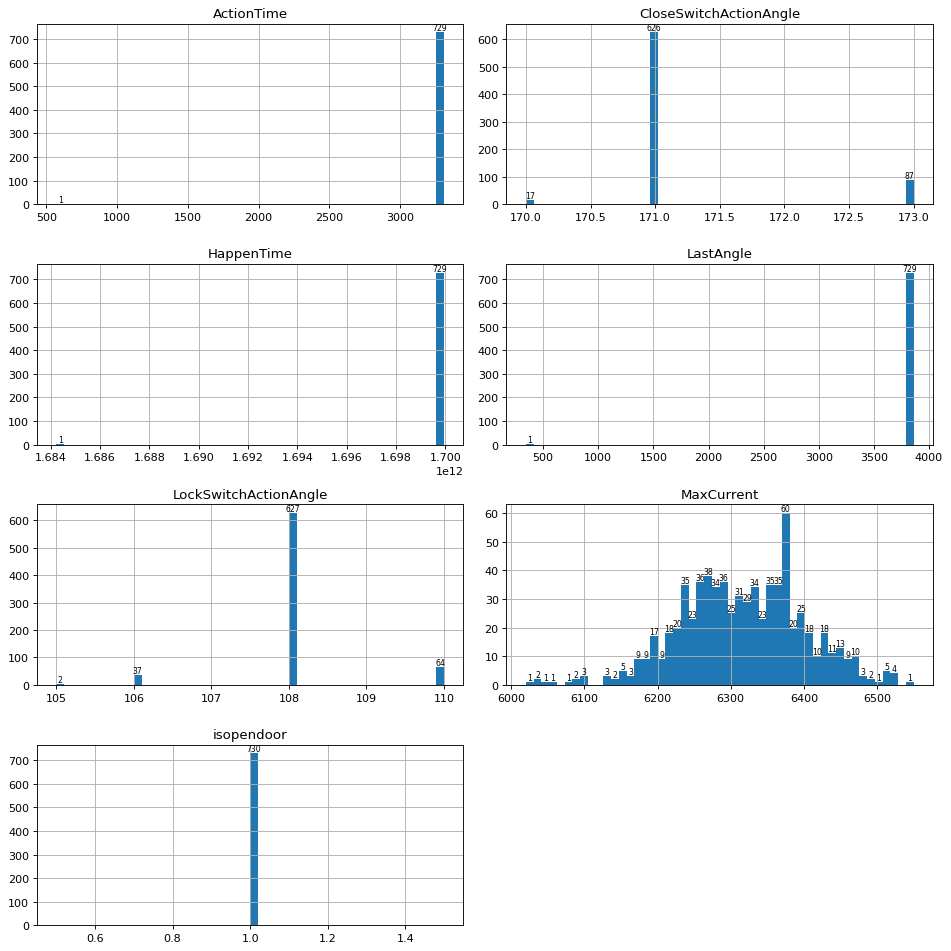

In [21]:
# check the histograms of each of the values
axes = normal_df_isopen[SCALAR_COLS].hist(bins=50, layout=(4, 2), figsize=(12, 12))
for ax in axes.ravel():
    for p in ax.patches:
        h = p.get_height()
        if h > 0:                                  # skip empty bins
            ax.annotate(int(h),
                        (p.get_x() + p.get_width() / 2, h),
                        ha="center", va="bottom", fontsize=7)
plt.tight_layout()
plt.show()

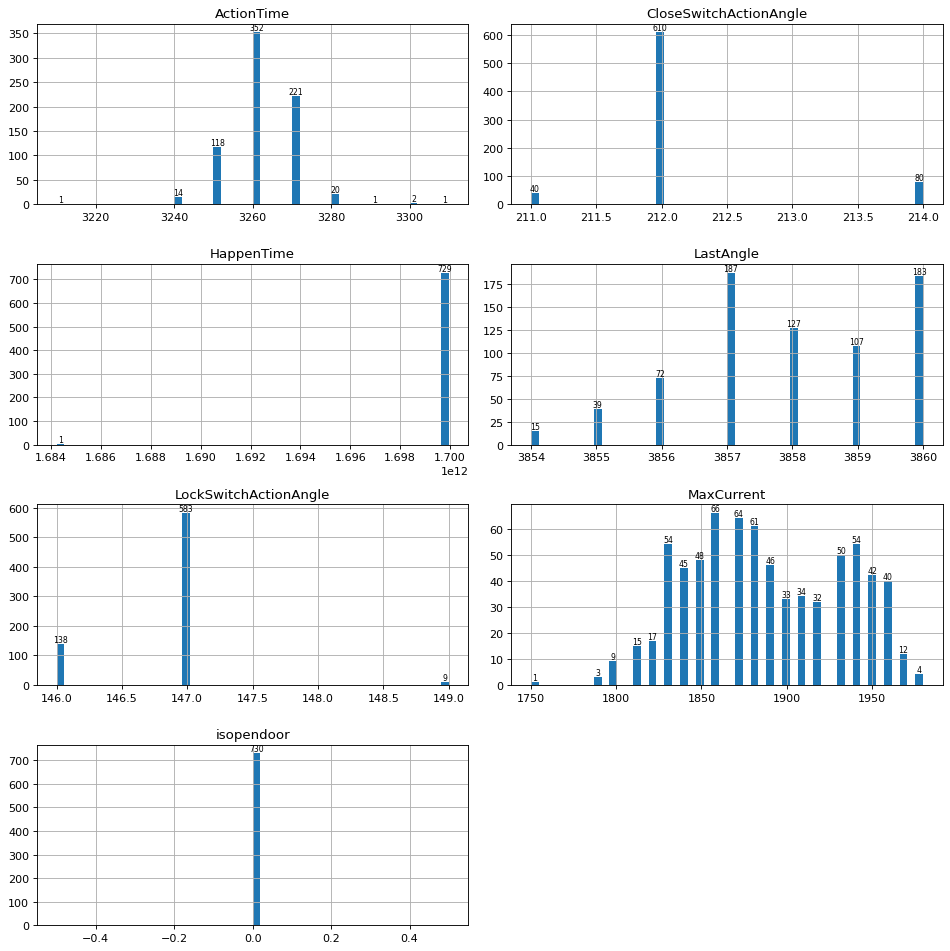

In [22]:
# # check the histograms of each of the values

axes = normal_df_isclosed[SCALAR_COLS].hist(bins=50, layout=(4, 2), figsize=(12, 12))
for ax in axes.ravel():
    for p in ax.patches:
        h = p.get_height()
        if h > 0:                                  # skip empty bins
            ax.annotate(int(h),
                        (p.get_x() + p.get_width() / 2, h),
                        ha="center", va="bottom", fontsize=7)
plt.tight_layout()
plt.show()

The hypothesis that there are two separate groups/peaks based on the new histograms seems to be true for ActionTime, CloseSwitchActionAngle, LockSwitchActionAngle and MaxCurrent. However, for LastAngle there was no separation of groups, so the chances of those values being associated with the flag for isopendoor is probably low. Plotting a correlation matrix points toward the same hypothesis.

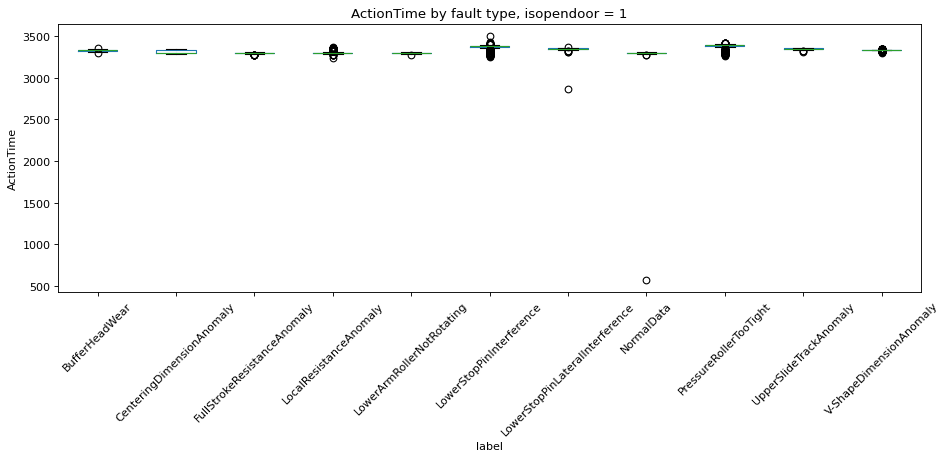

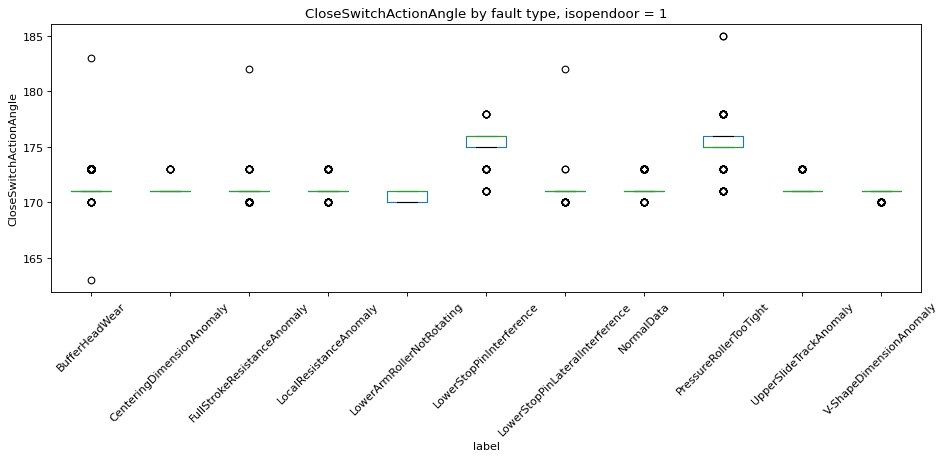

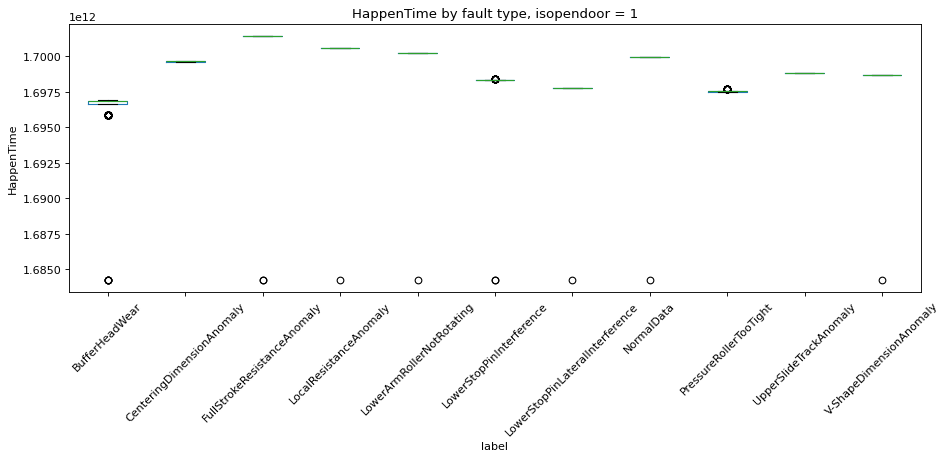

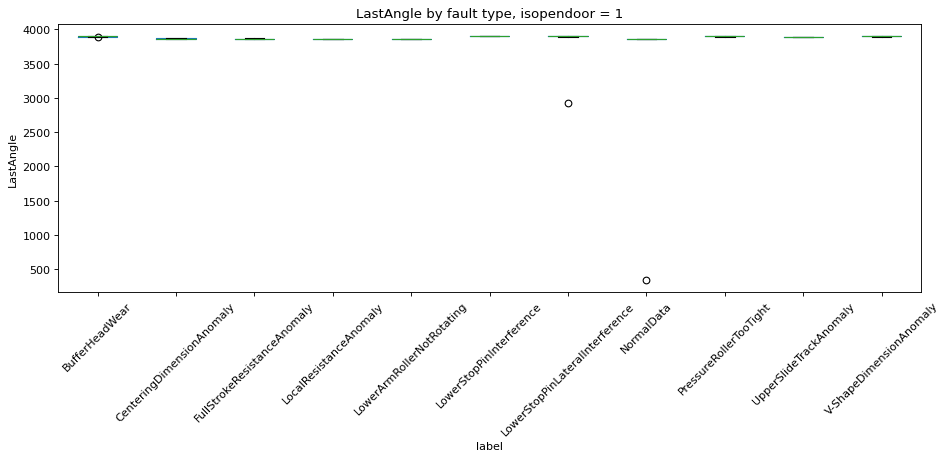

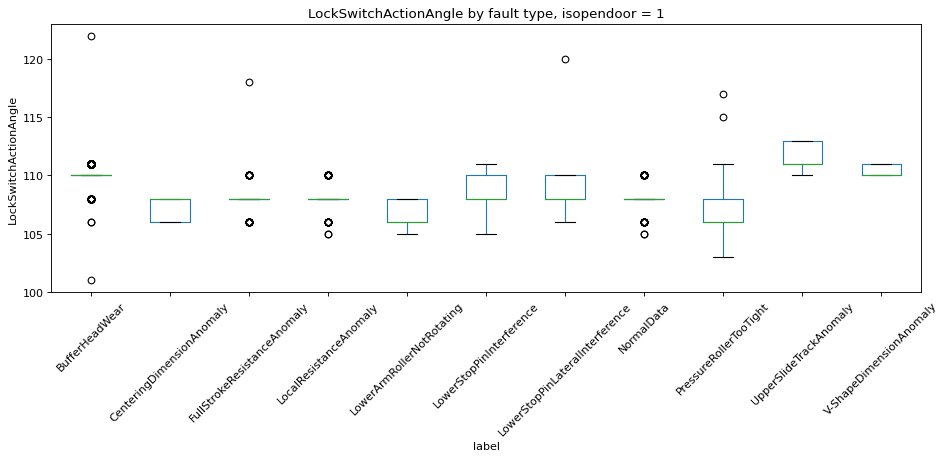

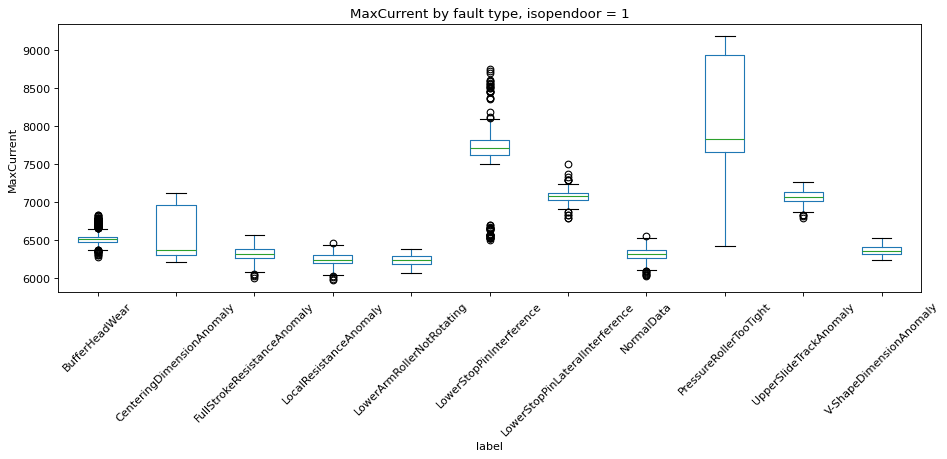

In [23]:
# start with isopendoor
df_door_open = df[df['isopendoor']==1]
cols = [col for col in SCALAR_COLS if col != 'isopendoor']

for col in cols:
    ax = df_door_open.boxplot(column=col, by="label", figsize=(12, 6), rot=45, grid=False)
    ax.set_title(f"{col} by fault type, isopendoor = 1")
    ax.set_xlabel("label")
    ax.set_ylabel(f"{col}")
    plt.suptitle("")          # pandas adds an automatic "Boxplot grouped by label" title; this clears it
    plt.tight_layout()
    plt.show()

Will first investigate then potentially remove some of the data points that seem to point towards either an aborted door cycle (fault) or a truncated/corrupted data point (anomaly). More investigation needs to be done in this area. 

That includes the low ActionTime point in the LowerStopPinInterference dataset and low LastAngle in the LowerStopPinInterference dataset. The other boxplots don't seem to point very clearly to corrupted datapoints, so I will keep them as they are.

In [24]:
print(df_door_open[df_door_open['ActionTime']<3000].index)
print(df_door_open[df_door_open['LastAngle']<3000].index)



Index([5572, 6296], dtype='int64')
Index([5572, 6296], dtype='int64')


In [25]:
df_door_open['n_samples'].describe()

count    4763.000000
mean      445.490447
std         6.048355
min       134.000000
25%       442.000000
50%       447.000000
75%       448.000000
max       462.000000
Name: n_samples, dtype: float64

In [26]:
# examine these two indices to see if it may be a fault or a corrupt data point
df_door_open[df_door_open.index.isin(df_door_open[df_door_open['ActionTime']<3000].index)]['n_samples']

5572    366
6296    134
Name: n_samples, dtype: int64

Since the number of waveform data points are much smaller than the rest of the df_door_open data (>>2 standard devations from the 25th percentile), I will treat these data points as corrupt/incomplete and remove them from the dataset

In [27]:
# anomaly for ActionTime and LastAngle is the same data point, remove
df_door_open = df_door_open[df_door_open['ActionTime']>3000]

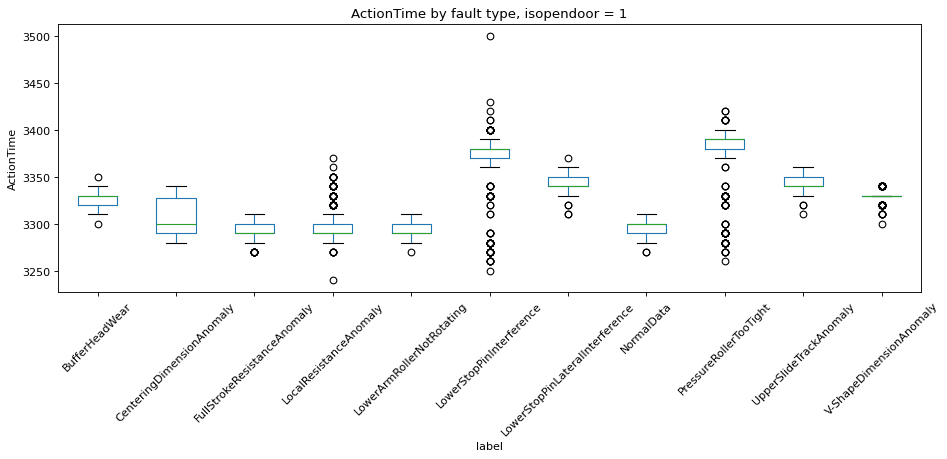

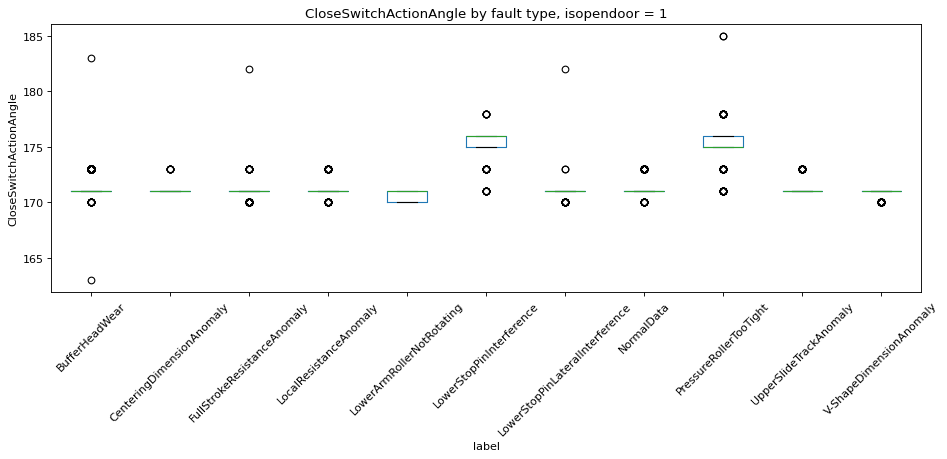

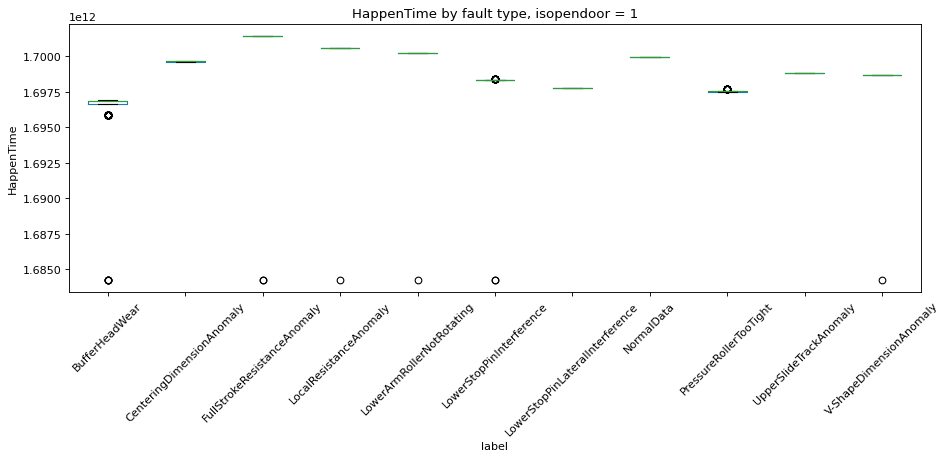

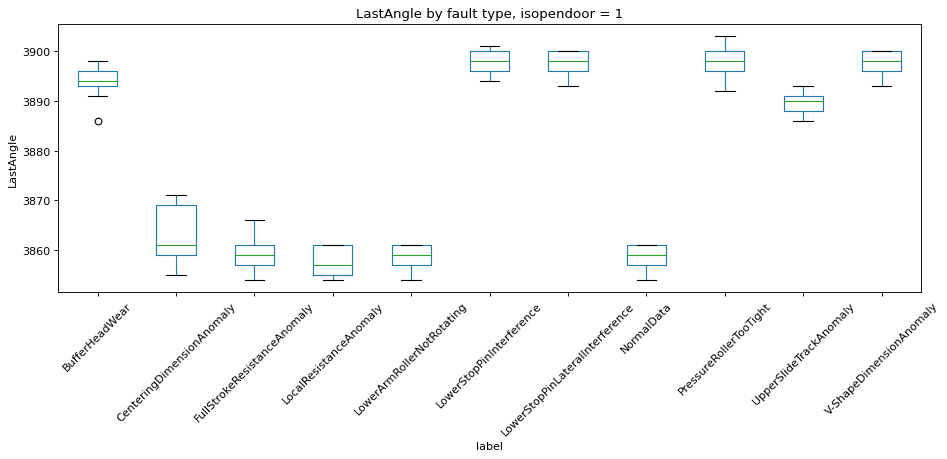

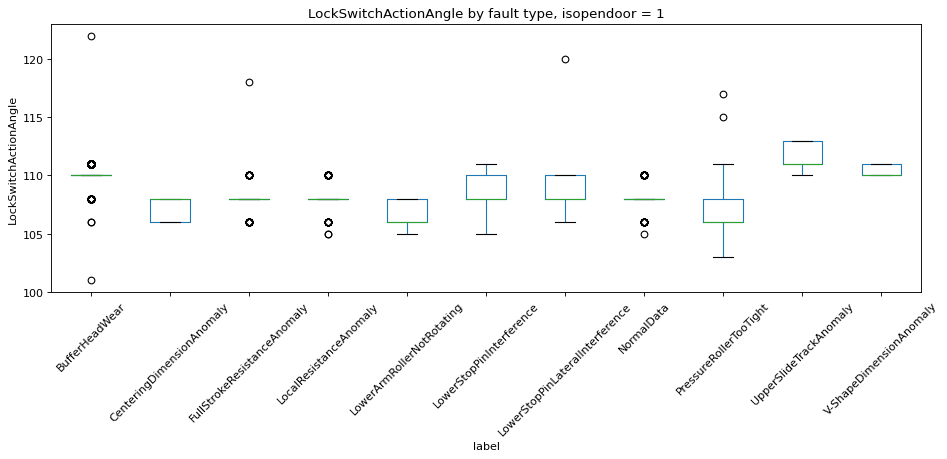

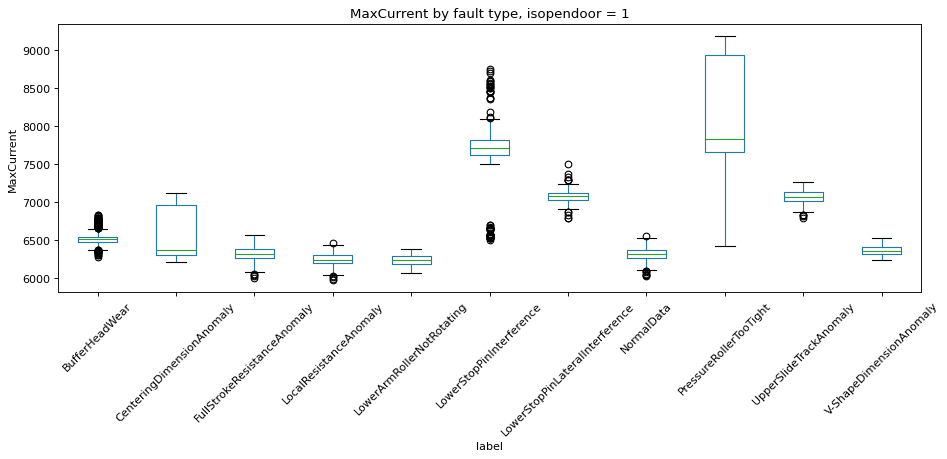

In [28]:
# look at distribution differences
cols = [col for col in SCALAR_COLS if col != 'isopendoor']

for col in cols:
    ax = df_door_open.boxplot(column=col, by="label", figsize=(12, 6), rot=45, grid=False)
    ax.set_title(f"{col} by fault type, isopendoor = 1")
    ax.set_xlabel("label")
    ax.set_ylabel(f"{col}")
    plt.suptitle("")          # pandas adds an automatic "Boxplot grouped by label" title; this clears it
    plt.tight_layout()
    plt.show()

There are some differences in the distribution of scalar values for certain fault types when compared against NormalData. These can potentially be used for anomaly detection 

Next, do the same for isopendoor = 0

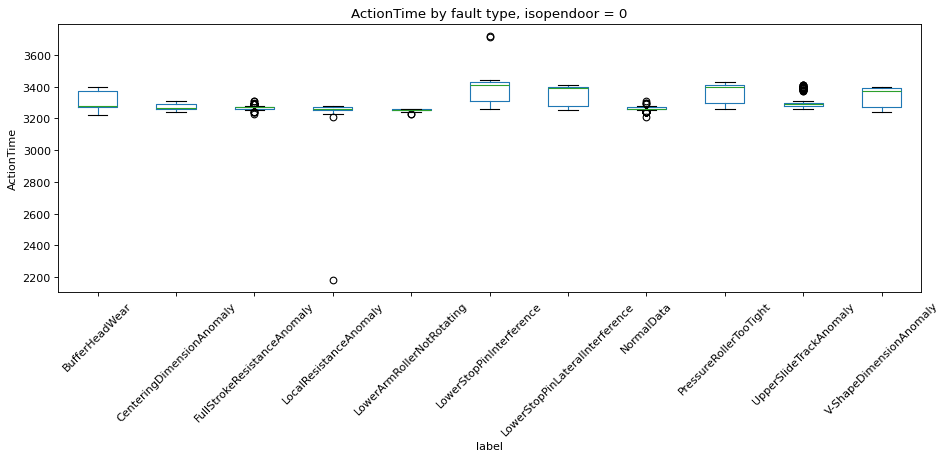

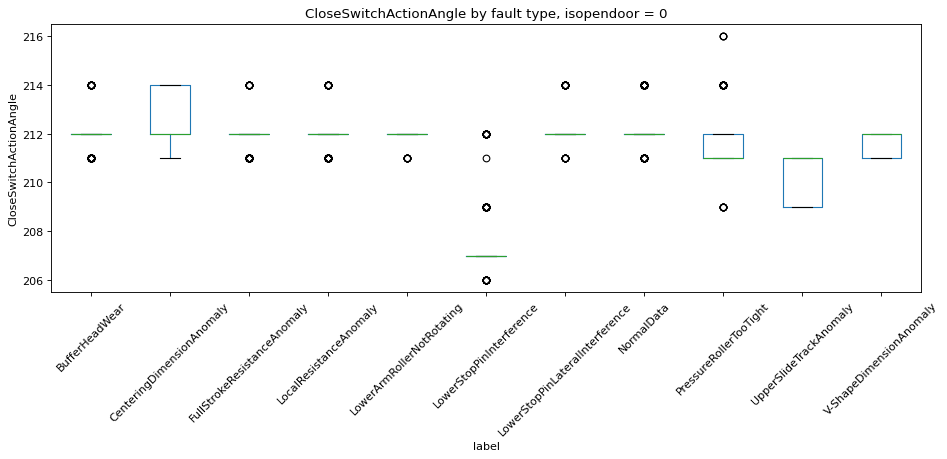

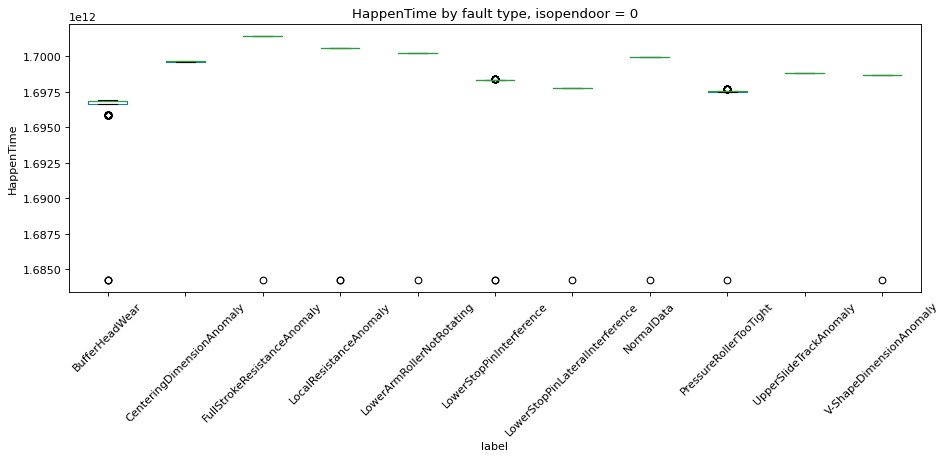

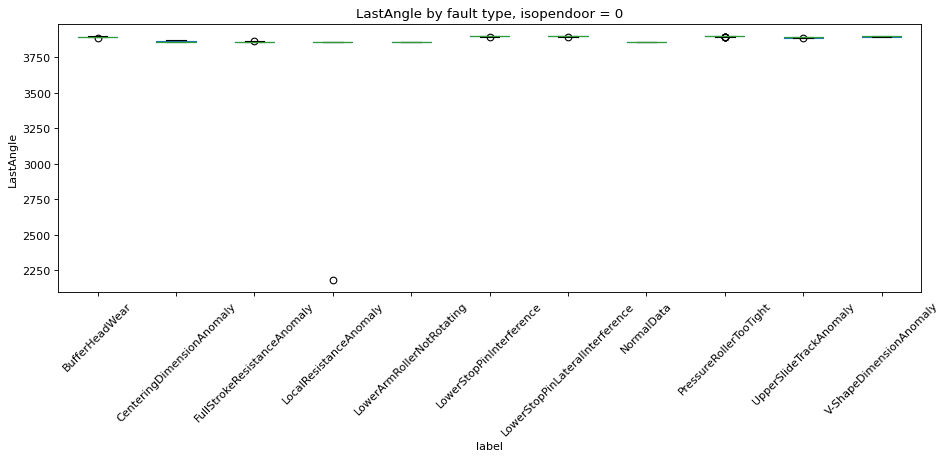

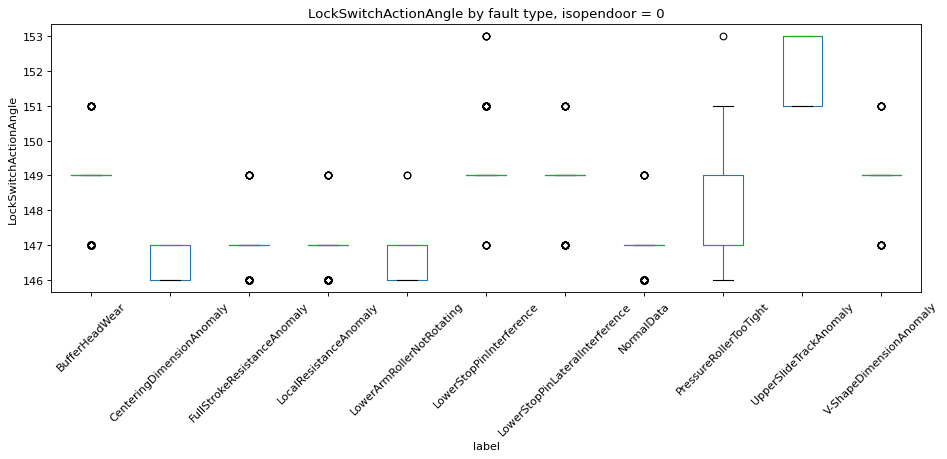

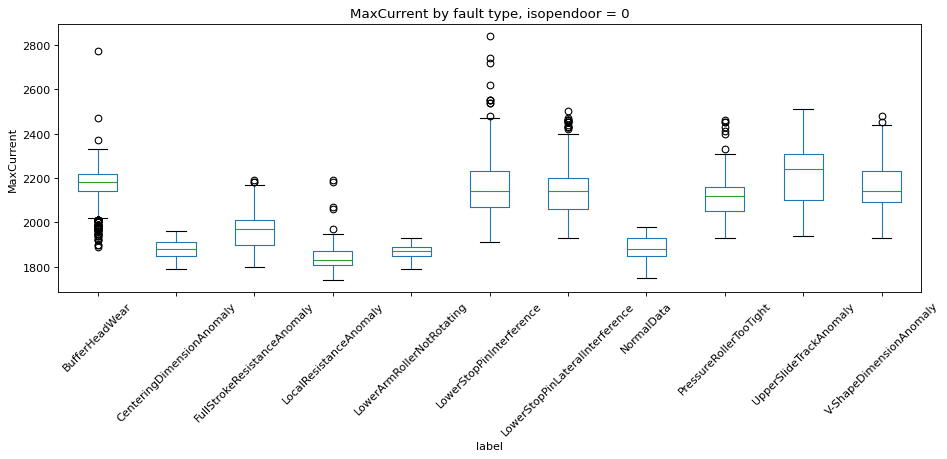

In [29]:
df_door_closed = df[df['isopendoor']==0]

for col in cols:
    ax = df_door_closed.boxplot(column=col, by="label", figsize=(12, 6), rot=45, grid=False)
    ax.set_title(f"{col} by fault type, isopendoor = 0")
    ax.set_xlabel("label")
    ax.set_ylabel(f"{col}")
    plt.suptitle("")          # pandas adds an automatic "Boxplot grouped by label" title; this clears it
    plt.tight_layout()
    plt.show()

In [30]:
print(df_door_closed[df_door_closed['ActionTime']<3000].index)
print(df_door_closed[df_door_closed['LastAngle']<3000].index)



Index([3612], dtype='int64')
Index([3612], dtype='int64')


In [31]:
df_door_closed['n_samples'].describe()

count    4768.000000
mean      430.884228
std        32.117985
min       270.000000
25%       414.000000
50%       424.000000
75%       426.000000
max       649.000000
Name: n_samples, dtype: float64

In [32]:
# examine these two indices to see if it may be a fault or a corrupt data point
df_door_closed[df_door_closed.index.isin(df_door_closed[df_door_closed['ActionTime']<3000].index)]['n_samples']

3612    270
Name: n_samples, dtype: int64

Similar to above, since the number of waveform data points are much smaller than the rest of the df_door_closed data (>>2 standard devations from the 25th percentile), I will treat these data points as corrupt/incomplete and remove them from the dataset

In [33]:
# anomaly for ActionTime and LastAngle is the same data point, remove
df_door_closed = df_door_closed[df_door_closed['ActionTime']>3000]

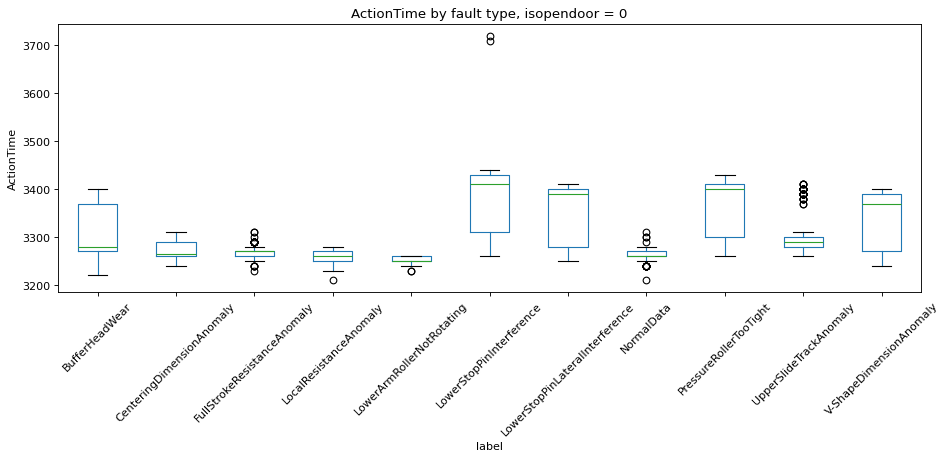

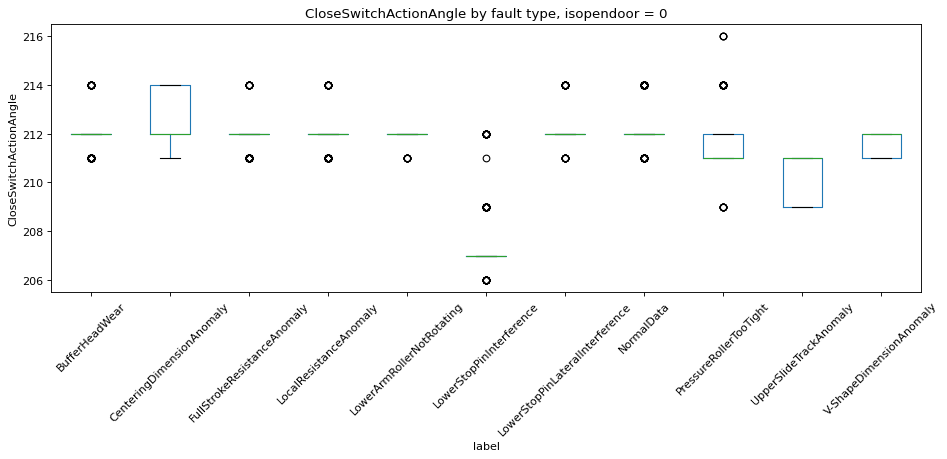

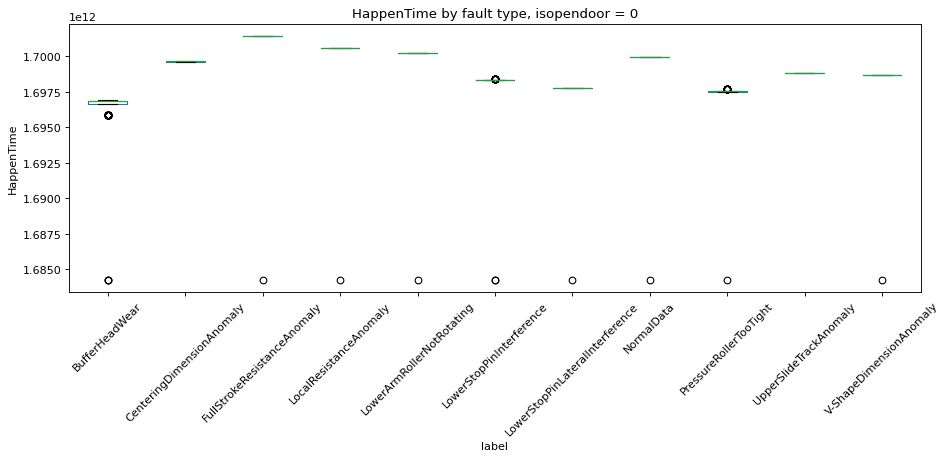

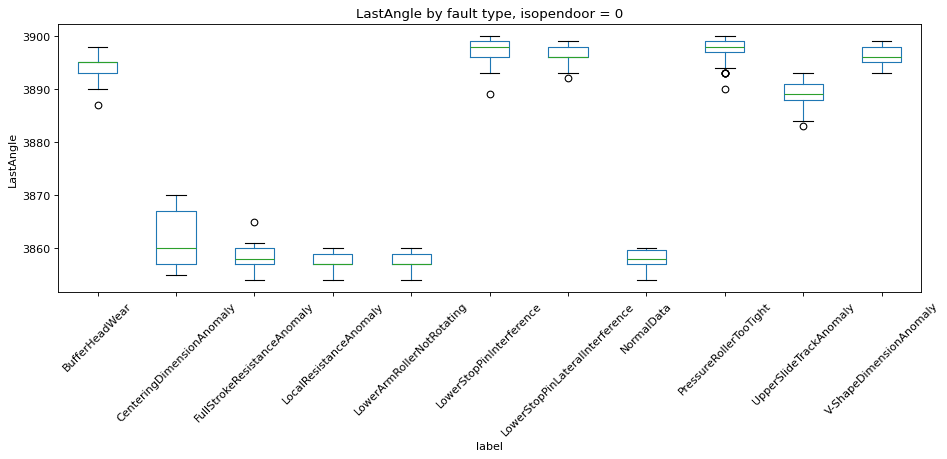

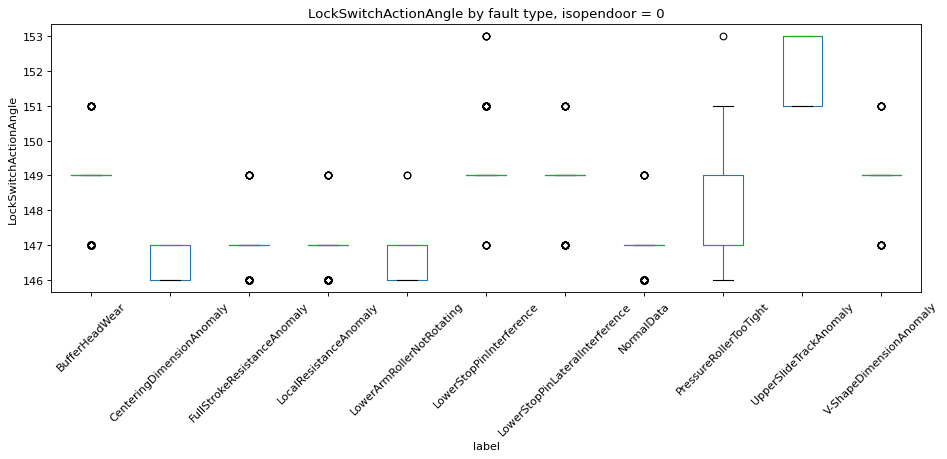

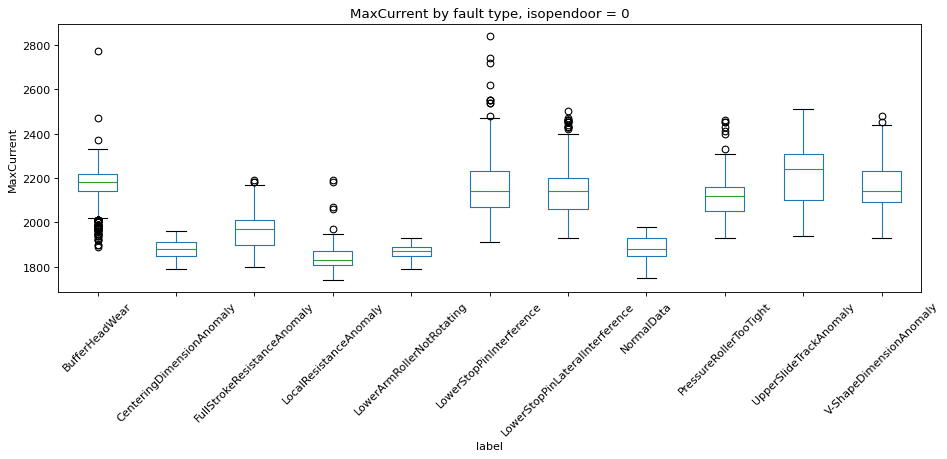

In [34]:
for col in cols:
    ax = df_door_closed.boxplot(column=col, by="label", figsize=(12, 6), rot=45, grid=False)
    ax.set_title(f"{col} by fault type, isopendoor = 0")
    ax.set_xlabel("label")
    ax.set_ylabel(f"{col}")
    plt.suptitle("")          # pandas adds an automatic "Boxplot grouped by label" title; this clears it
    plt.tight_layout()
    plt.show()

In [35]:
normal_df = normal_df[normal_df['ActionTime']>3000]

### Waveform data

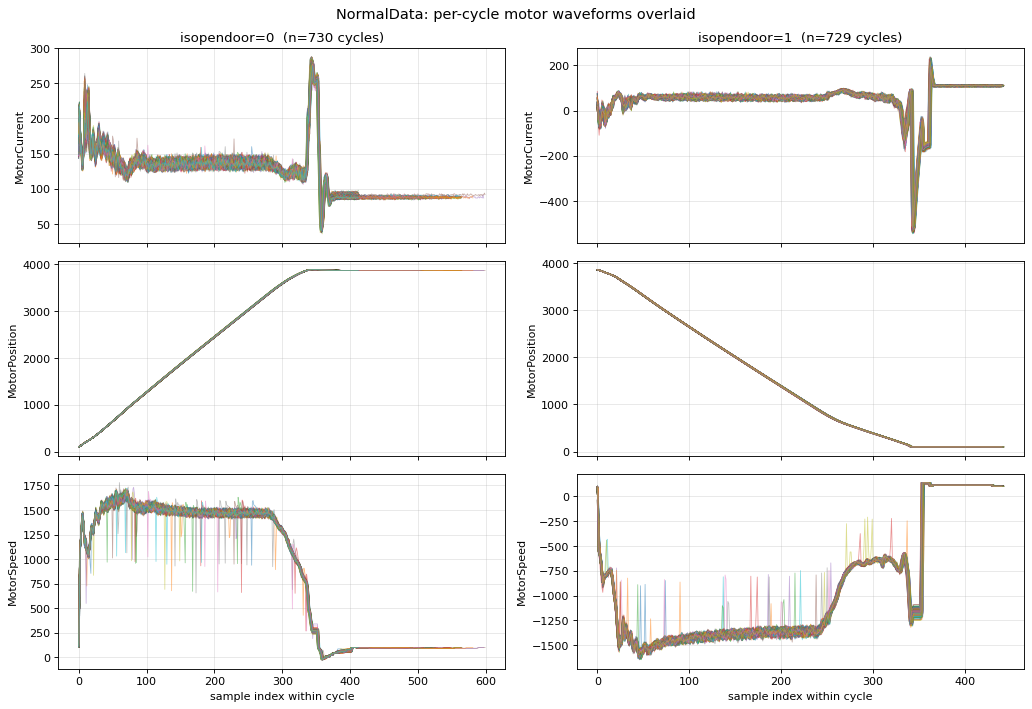

In [36]:
fig, ax = plt.subplots(3, 2, figsize=(13, 9), sharex="col")
for col, grp in enumerate([0, 1]):
    sub = normal_df[normal_df["isopendoor"] == grp]
    for _, r in sub.iterrows():
        for row, w in enumerate(WAVEFORM_COLS):
            ax[row, col].plot(r[w], lw=0.7, alpha=0.5)
    for row, w in enumerate(WAVEFORM_COLS):
        ax[row, col].set_ylabel(w)
        ax[row, col].grid(alpha=0.3)
    ax[0, col].set_title(f"isopendoor={grp}  (n={len(sub)} cycles)")
    ax[2, col].set_xlabel("sample index within cycle")
fig.suptitle("NormalData: per-cycle motor waveforms overlaid", fontsize=13)
fig.tight_layout()
fig.savefig("eda_normal_overlay.png", dpi=110)
plt.show()

The graphs generally show a clear signal for both open and close door groups, especially for MotorCurrent and MotorPosition waveform behavior. MotorSpeed shows spikes coming off the main signal periodically but generally goes back to the mean very quickly. Since these are normal cycles, it seems more likely that these spikes come from sensor noise rather than it being a true signal. The data should therefore be smoothed out for such spikes.




In [37]:
def despike(arr, win=5, n_sigma=4):
    s = pd.Series(arr)
    med = s.rolling(win, center=True, min_periods=1).median()
    mad = (s - med).abs().rolling(win, center=True, min_periods=1).median()
    spike = (s - med).abs() > n_sigma * 1.4826 * mad.replace(0, np.nan)
    return s.where(~spike, med).to_numpy()

df_door_open['MotorSpeedSmoothed'] = df_door_open['MotorSpeed'].apply(lambda x: despike(x))
df_door_closed['MotorSpeedSmoothed'] = df_door_closed['MotorSpeed'].apply(lambda x: despike(x))

In [38]:
normal_df['MotorSpeedSmoothed'] = normal_df['MotorSpeed'].apply(lambda x: despike(x))

One can also assume that the waveforms should be largely independent of time (HappenTime). Examining the waveform patterns over HappenTime can be a good way to detect if there is sensor drift over time as the sensor keeps operating. Analysis will be done after feature engineering the waveforms to measure the drift over HappenTime of key points of the wave.

Finally, overlaying waveform characteristics can also be a way to do anomaly detection by comparing against the normal waveforms

There is also no time or x-axis for the waveform data, so it has to be assumed that each value in the array is equally spaced out or spaced out in a standardized manner. I had the hypothesis of using the offsets from the signal data as the time axis, but the intervals/number of points do not line up.

Based on the constant interval assumption, create a smoothed curved with linear interpolation to capture the general shape of a normal curve. Also, smoothing will only be used for visualization purely to make the normal waveform plots readable, and no smoothed values will enter the features

In [39]:
int(df_door_open['n_samples'].mean()+df_door_closed['n_samples'].mean())


876

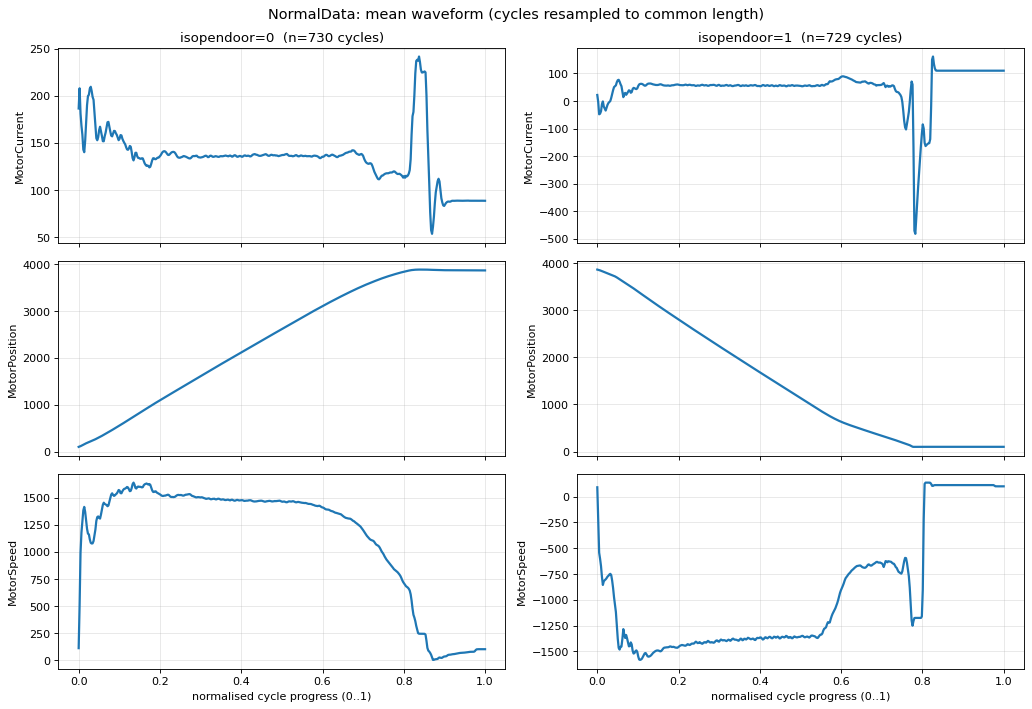

In [40]:
N = int((df_door_open['n_samples'].mean()+df_door_closed['n_samples'].mean())/2)
# common grid length; cycles get resampled to this many points

def resample(arr, n=N):
    """Stretch/compress one cycle onto n evenly spaced points by linear interpolation."""
    arr = np.asarray(arr, dtype=float)
    return np.interp(np.linspace(0, 1, n), np.linspace(0, 1, len(arr)), arr)

fig, ax = plt.subplots(3, 2, figsize=(13, 9), sharex="col")
for col, grp in enumerate([0, 1]):
    sub = normal_df[normal_df["isopendoor"] == grp]
    for row, w in enumerate(WAVEFORM_COLS):
        stack = np.vstack([resample(r) for r in sub[w]])  # shape (n_cycles, N)
        mean = stack.mean(axis=0)
        ax[row, col].plot(np.linspace(0, 1, N), mean, color="tab:blue", lw=2)
        ax[row, col].set_ylabel(w)
        ax[row, col].grid(alpha=0.3)
    ax[0, col].set_title(f"isopendoor={grp}  (n={len(sub)} cycles)")
    ax[2, col].set_xlabel("normalised cycle progress (0..1)")
fig.suptitle("NormalData: mean waveform (cycles resampled to common length)", fontsize=13)
fig.tight_layout()
plt.show()

In [41]:
df_door_open['label'].unique()

array(['BufferHeadWear', 'CenteringDimensionAnomaly',
       'FullStrokeResistanceAnomaly', 'LocalResistanceAnomaly',
       'LowerArmRollerNotRotating', 'LowerStopPinInterference',
       'LowerStopPinLateralInterference', 'NormalData',
       'PressureRollerTooTight', 'UpperSlideTrackAnomaly',
       'V-ShapeDimensionAnomaly'], dtype=object)

Plot each fault type against the normal curve

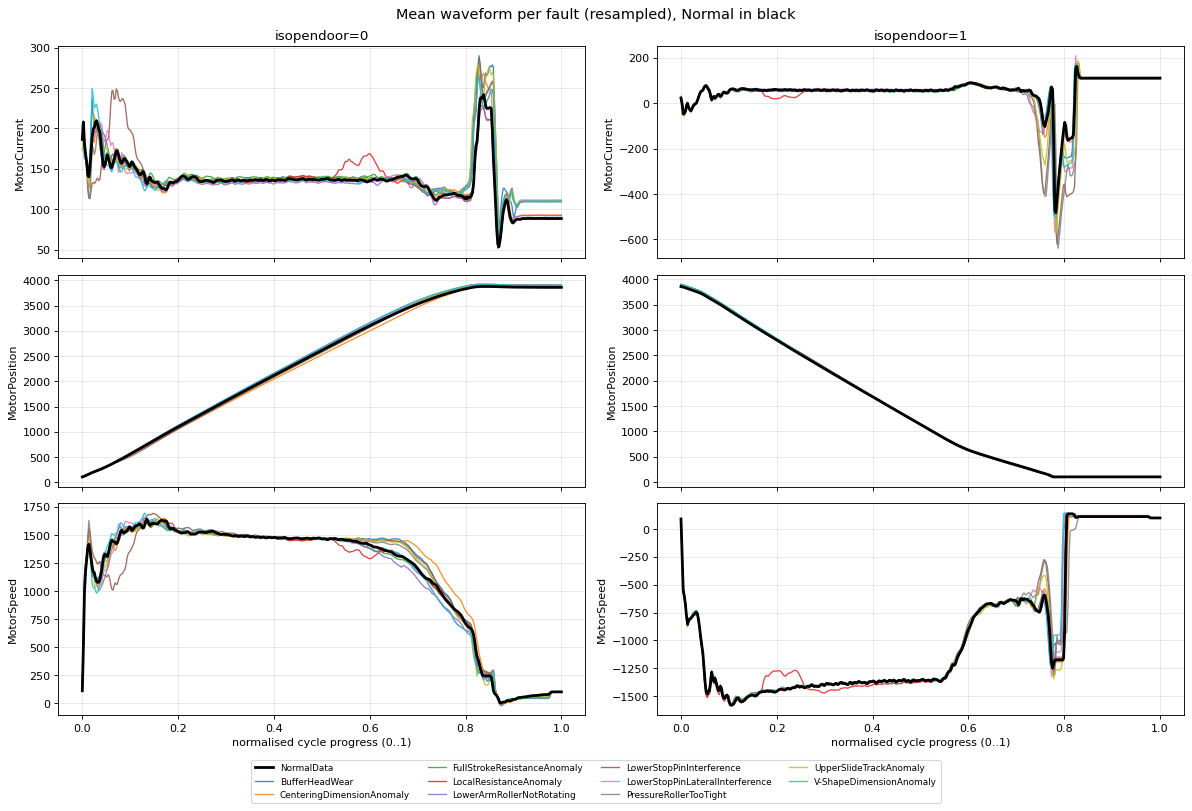

In [42]:
N = int((df_door_open['n_samples'].mean() + df_door_closed['n_samples'].mean()) / 2)

def resample(arr, n=N):
    arr = np.asarray(arr, dtype=float)
    return np.interp(np.linspace(0, 1, n), np.linspace(0, 1, len(arr)), arr)

def mean_curve(sub, w):
    return np.vstack([resample(r) for r in sub[w]]).mean(axis=0)

faults = sorted(set(df["label"]) - {"NormalData"})
colors = plt.cm.tab10(np.linspace(0, 1, len(faults)))
x = np.linspace(0, 1, N)

fig, ax = plt.subplots(3, 2, figsize=(15, 10), sharex="col")
for col, grp in enumerate([0, 1]):
    nsub = normal_df[normal_df["isopendoor"] == grp]
    for row, w in enumerate(WAVEFORM_COLS):
        ax[row, col].plot(x, mean_curve(nsub, w), color="black", lw=2.5, zorder=10, label="NormalData")
        for fl, c in zip(faults, colors):
            fsub = df[(df["label"] == fl) & (df["isopendoor"] == grp)]
            if len(fsub) == 0:
                continue
            ax[row, col].plot(x, mean_curve(fsub, w), color=c, lw=1.2, alpha=0.85, label=fl)
        ax[row, col].set_ylabel(w)
        ax[row, col].grid(alpha=0.3)
    ax[0, col].set_title(f"isopendoor={grp}")
    ax[2, col].set_xlabel("normalised cycle progress (0..1)")

h, l = ax[0, 0].get_legend_handles_labels()
fig.legend(h, l, loc="lower center", ncol=4, fontsize=8, bbox_to_anchor=(0.5, -0.02))
fig.suptitle("Mean waveform per fault (resampled), Normal in black", fontsize=13)
fig.tight_layout(rect=[0, 0.04, 1, 1])
plt.show()

Averaging each of the fault types shows that there are anomalies in the wave patterns or amplitudes for different fault types when compared to the normal. 

### Digital Data

In [43]:
DIGITAL_COLS

['CloseSwitch',
 'DoorEnabled',
 'FullyLock',
 'FullyOpen',
 'LockSwitch',
 'ZeroSpeed']

Check the Digital Columns for unique values of offset and value

In [44]:
for col in DIGITAL_COLS:
    print(col)
    print({v[0] for row in df[col] for v in row})
    print({v[1] for row in df[col] for v in row})


CloseSwitch
{0, 9, 10, 11, 19, 20, 21, 22, 29, 30, 31, 32, 38, 39, 40, 41, 42, 48, 49, 50, 51, 52, 54, 59, 60, 61, 62, 63, 68, 69, 70, 71, 72, 79, 80, 81, 82, 89, 90, 91, 92, 99, 100, 101, 102, 103, 108, 109, 110, 111, 112, 119, 120, 121, 122, 123, 124, 129, 130, 131, 132, 139, 140, 141, 142, 149, 150, 151, 152, 159, 160, 161, 162, 169, 170, 171, 172, 179, 180, 181, 182, 189, 190, 191, 192, 199, 200, 201, 202, 209, 210, 211, 212, 219, 220, 221, 222, 229, 230, 231, 232, 239, 240, 241, 242, 249, 250, 251, 252, 259, 260, 261, 262, 269, 270, 271, 272, 279, 280, 281, 282, 290, 291, 292, 300, 301, 302, 309, 310, 311, 312, 320, 321, 322, 330, 331, 332, 339, 340, 341, 342, 350, 351, 352, 360, 361, 362, 370, 371, 372, 380, 381, 382, 383, 390, 391, 392, 393, 394, 400, 401, 402, 403, 410, 411, 412, 413, 420, 421, 422, 423, 430, 431, 432, 433, 440, 441, 442, 443, 450, 451, 452, 453, 459, 460, 461, 462, 463, 470, 471, 472, 473, 480, 481, 482, 483, 484, 490, 491, 492, 493, 494, -7701, 499, 500, 501,

For the Digital/Switch Columns, the value is constant for all columns except FullyOpen, and only the offset changes. 100 and 101 toggles many times per cycle, so it's unclear what it means in the context of FullyOpen. It also seem like the offset values may be repeated across columns. Check if the offsets are the same across all columns and if they are, then visualization/anomaly prediction can be done on just one of the Digital/Switch columns as a proxy for all. 

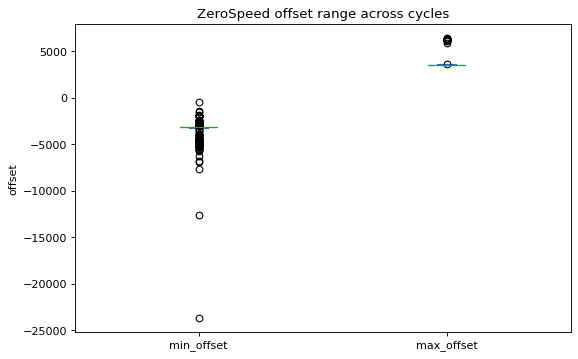

In [45]:
df_door_open["min_offset"] = df_door_open["ZeroSpeed"].apply(lambda s: min(t[0] for t in s))
df_door_open["max_offset"] = df_door_open["ZeroSpeed"].apply(lambda s: max(t[0] for t in s))

df_door_open[["min_offset", "max_offset"]].plot(kind="box", figsize=(8, 5))
plt.ylabel("offset")
plt.title("ZeroSpeed offset range across cycles")
plt.show()

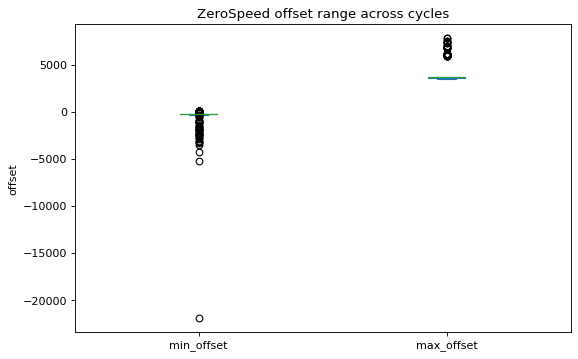

In [46]:
df_door_closed["min_offset"] = df_door_closed["ZeroSpeed"].apply(lambda s: min(t[0] for t in s))
df_door_closed["max_offset"] = df_door_closed["ZeroSpeed"].apply(lambda s: max(t[0] for t in s))

df_door_closed[["min_offset", "max_offset"]].plot(kind="box", figsize=(8, 5))
plt.ylabel("offset")
plt.title("ZeroSpeed offset range across cycles")
plt.show()

Those points far out may be anomalies but for these rows the scalar values and waveform values are not anomalous, so it could possibly be a time offset logging issue from the sensors. The determination is to keep the data points as valid

In [47]:
all_match = True

for _, row in df.iterrows():

    reference_offsets = [t[0] for t in row[DIGITAL_COLS[0]]]

    for col in DIGITAL_COLS[1:]:
        offsets = [t[0] for t in row[col]]

        if offsets != reference_offsets:
            all_match = False
            break

    if not all_match:
        break

print(all_match)
# All digital switch columns have the same offset values across rows.

True


Plot a subset of Digital Data for Normal values against fault values just to take a look

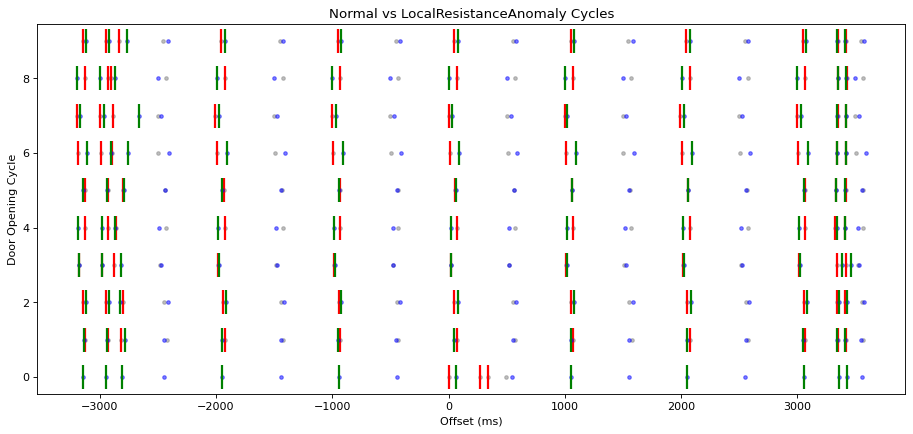

In [48]:
import matplotlib.pyplot as plt

n_cycles = 10

fault_df = df_door_open[df_door_open['label'] == 'LocalResistanceAnomaly']

fig, ax = plt.subplots(figsize=(14, 6))

# -------------------------
# Normal cycles
# -------------------------
for cycle_idx, row_idx in enumerate(normal_df_isopen.index[:n_cycles]):

    signal = normal_df_isopen.loc[row_idx, 'ZeroSpeed']

    offsets = [t[0] for t in signal]

    ax.scatter(
        offsets,
        [cycle_idx] * len(offsets),
        s=10,
        alpha=0.5,
        color='gray',
        label='Normal ZeroSpeed' if cycle_idx == 0 else ""
    )

    fullyopen_signal = normal_df_isopen.loc[row_idx, 'FullyOpen']

    for offset, value in fullyopen_signal:
        if value == 101:
            ax.scatter(
                offset,
                cycle_idx,
                marker='|',
                s=500,
                linewidths=2,
                color='red',
                label='Normal FullyOpen=101' if cycle_idx == 0 else ""
            )

# -------------------------
# Fault cycles
# -------------------------
for cycle_idx, row_idx in enumerate(fault_df.index[:n_cycles]):

    signal = fault_df.loc[row_idx, 'ZeroSpeed']

    offsets = [t[0] for t in signal]

    ax.scatter(
        offsets,
        [cycle_idx] * len(offsets),
        s=10,
        alpha=0.5,
        color='blue',
        label='LocalResistanceAnomaly ZeroSpeed' if cycle_idx == 0 else ""
    )

    fullyopen_signal = fault_df.loc[row_idx, 'FullyOpen']

    for offset, value in fullyopen_signal:
        if value == 101:
            ax.scatter(
                offset,
                cycle_idx,
                marker='|',
                s=500,
                linewidths=2,
                color='green',
                label='LocalResistanceAnomaly FullyOpen=101' if cycle_idx == 0 else ""
            )

ax.set_xlabel('Offset (ms)')
ax.set_ylabel('Door Opening Cycle')
ax.set_title('Normal vs LocalResistanceAnomaly Cycles')

# ax.legend()
plt.show()

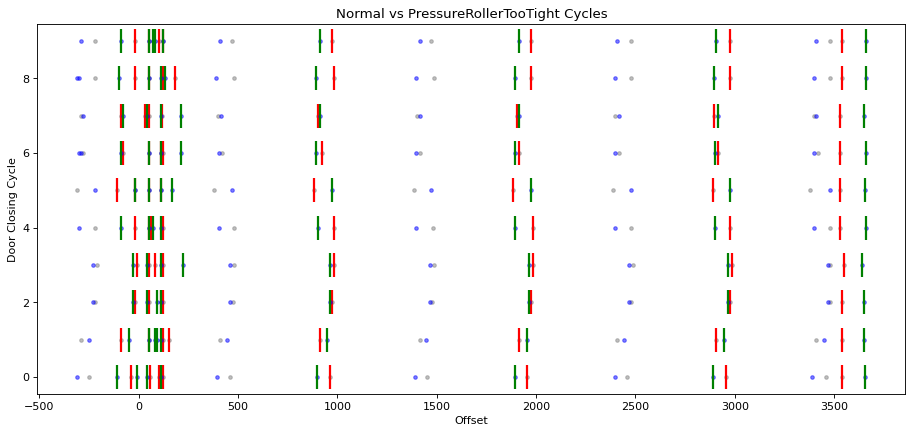

In [49]:
import matplotlib.pyplot as plt

n_cycles = 10

fault_df = df_door_closed[df_door_closed['label'] == 'PressureRollerTooTight']

fig, ax = plt.subplots(figsize=(14, 6))

# -------------------------
# Normal cycles
# -------------------------
for cycle_idx, row_idx in enumerate(normal_df_isclosed.index[:n_cycles]):

    signal = normal_df_isclosed.loc[row_idx, 'ZeroSpeed']

    offsets = [t[0] for t in signal]

    ax.scatter(
        offsets,
        [cycle_idx] * len(offsets),
        s=10,
        alpha=0.5,
        color='gray',
        label='Normal ZeroSpeed' if cycle_idx == 0 else ""
    )

    fullyopen_signal = normal_df_isclosed.loc[row_idx, 'FullyOpen']

    for offset, value in fullyopen_signal:
        if value == 101:
            ax.scatter(
                offset,
                cycle_idx,
                marker='|',
                s=500,
                linewidths=2,
                color='red',
                label='Normal FullyOpen=101' if cycle_idx == 0 else ""
            )

# -------------------------
# Fault cycles
# -------------------------
for cycle_idx, row_idx in enumerate(fault_df.index[:n_cycles]):

    signal = fault_df.loc[row_idx, 'ZeroSpeed']

    offsets = [t[0] for t in signal]

    ax.scatter(
        offsets,
        [cycle_idx] * len(offsets),
        s=10,
        alpha=0.5,
        color='blue',
        label='PressureRollerTooTight ZeroSpeed' if cycle_idx == 0 else ""
    )

    fullyopen_signal = fault_df.loc[row_idx, 'FullyOpen']

    for offset, value in fullyopen_signal:
        if value == 101:
            ax.scatter(
                offset,
                cycle_idx,
                marker='|',
                s=500,
                linewidths=2,
                color='green',
                label='PressureRollerTooTight FullyOpen=101' if cycle_idx == 0 else ""
            )

ax.set_xlabel('Offset')
ax.set_ylabel('Door Closing Cycle')
ax.set_title('Normal vs PressureRollerTooTight Cycles')

# ax.legend()
plt.show()


It's not clear what signals there are here for now. What it shows though is that the offsets for each row of data are slightly different, and one can interpret the min and max offsets as the entire duration of a measurement (row). The offsets do not necessarily give per-sample timestamps, but the span divided by sample count gives a stable average interval, which I use to justify an equal spacing assumption for the waveform data. 

In [50]:
# get average offset duration between each waveform data measurement
def offset_span(s):
    offs = [t[0] for t in s]         
    return max(offs) - min(offs)

df_door_open['measurement_average_offset'] = (
    df_door_open['ZeroSpeed'].apply(offset_span) / df_door_open['n_samples']
)

df_door_closed['measurement_average_offset'] = (
    df_door_closed['ZeroSpeed'].apply(offset_span) / df_door_closed['n_samples']
)

<Axes: >

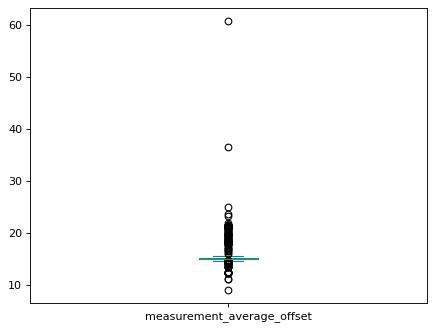

In [51]:
df_door_open['measurement_average_offset'].plot.box()

<Axes: >

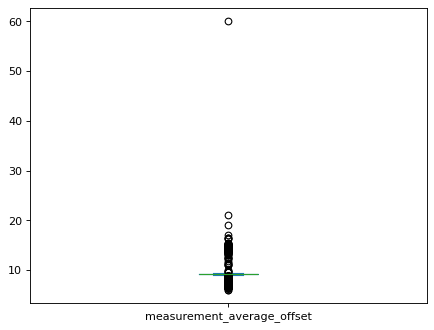

In [52]:
df_door_closed['measurement_average_offset'].plot.box()

Looking at the average offset between each waveform data point, besides some anomalies arising from the extreme values of the offset values found earlier, they all cluster in a pretty tight band. Thus, it shall be assumed that all the rows are meant to have similar sampling intervals for waveform data.

## Feature Engineering

Feature engineering is now to be done to prepare the dataset for anomaly detection. Because sensor readings have varying lengths and are in the wrong format for the model, it cannot be used directly as is. Feature engineering helps to capture the key variables needed to be used as input for the model, which it will then use as part of the feature set to determine if the door operations are normal or faulty. 

For waveform data, the data should capture the key wave features like amplitudes, mean and standard deviation values, plateaus where the magnitude does not change much, and ending positions

The value and offsets of the digital signals alone seem to not carry any discriminating signal that can be used for anomaly detection. Therefore they will be left out of the features use for anomaly detection.

In [53]:
df_door_open[SCALAR_COLS]

,ActionTime,CloseSwitchActionAngle,HappenTime,LastAngle,LockSwitchActionAngle,MaxCurrent,isopendoor
1,3320,173.0,1695879434343,3894,108.0,6640,1
3,3330,173.0,1695879460439,3896,108.0,6750,1
5,3320,173.0,1695879482246,3893,108.0,6820,1
7,3320,173.0,1695879502137,3896,108.0,6680,1
9,3330,173.0,1695879854646,3896,108.0,6620,1
...,...,...,...,...,...,...,...
9524,3330,171.0,1698656507163,3894,110.0,6300,1
9526,3340,171.0,1698656529377,3898,110.0,6340,1
9528,3330,171.0,1698656552466,3900,111.0,6370,1
9530,3330,171.0,1698656572366,3900,110.0,6290,1


In [54]:
def cycle_features(cur, pos, spd):
    ac = np.asarray(cur)
    asp = np.asarray(spd)
    n = len(cur)
    t1, t2 = n//3, 2*n//3                         # to split the waves into three segments/phases
    return dict(
        dur=n,                                    # duration: length of array for waveform data/cycle length
        peak_cur=np.abs(ac).max(),                # maximum peak motor current in waveform data
        mean_cur=ac.mean(),                       # average motor current
        integral_cur=np.abs(ac).sum(),            # total absolute current 
        startup_peak=np.abs(ac[:t1]).max(),       # peak of motor current at start of door operations
        plateau_med=np.median(ac[t1:t2]),         # "plateau" portion of the current in the middle where current changes less
        plateau_std=ac[t1:t2].std(),              # variance of the waveform during the plateau phase
        endstop_peak=np.abs(ac[t2:]).max(),       # peak of motor current at the end of door operations
        cur_min=ac.min(),                         # most negative current to detect if current reverses when it is not supposed to
        speed_max=np.abs(asp).max(),              # max motor speed
        speed_plateau_med=np.median(asp[t1:t2]),  # plateau portion of the motor speed
        pos_end=np.asarray(pos)[-1],              # end position of motor
    )

feat_eng_close = pd.DataFrame(
    [cycle_features(r.MotorCurrent, r.MotorPosition, r.MotorSpeed) for r in df_door_closed.itertuples()],
    index=df_door_closed.index,
)

feat_eng_open = pd.DataFrame(
    [cycle_features(r.MotorCurrent, r.MotorPosition, r.MotorSpeed) for r in df_door_open.itertuples()],
    index=df_door_open.index,
)

In [55]:
feat_eng_open

,dur,peak_cur,mean_cur,integral_cur,startup_peak,plateau_med,plateau_std,endstop_peak,cur_min,speed_max,speed_plateau_med,pos_end
1,448,554.0,41.982143,33744.0,79.0,56.0,11.933607,554.0,-554.0,1602.0,-1357.0,103.0
3,448,565.0,40.854911,33709.0,81.0,55.0,12.160226,565.0,-565.0,1555.0,-1356.0,103.0
5,448,572.0,40.486607,33616.0,78.0,54.0,12.812153,572.0,-572.0,1585.0,-1356.0,103.0
7,448,558.0,41.031250,33418.0,75.0,54.0,11.529596,558.0,-558.0,1592.0,-1361.0,103.0
9,448,552.0,42.225446,33159.0,77.0,54.0,11.560535,552.0,-552.0,1598.0,-1343.0,103.0
...,...,...,...,...,...,...,...,...,...,...,...,...
9524,447,520.0,46.785235,34775.0,84.0,58.0,10.231596,520.0,-520.0,1594.0,-1340.0,103.0
9526,449,524.0,47.158129,34808.0,87.0,60.0,10.198475,524.0,-524.0,1598.0,-1353.0,103.0
9528,448,527.0,47.848214,34464.0,83.0,59.0,10.519813,527.0,-527.0,1611.0,-1358.0,103.0
9530,448,519.0,46.437500,34932.0,78.0,59.0,9.417722,519.0,-519.0,1570.0,-1350.0,103.0


In [56]:
feat_eng_open = pd.concat([feat_eng_open, df_door_open[SCALAR_COLS], df_door_open["label"]], axis=1)
feat_eng_close = pd.concat([feat_eng_close, df_door_closed[SCALAR_COLS], df_door_closed["label"]], axis=1)

In [57]:
feat_eng_open.head()

,dur,peak_cur,mean_cur,integral_cur,startup_peak,plateau_med,plateau_std,endstop_peak,cur_min,speed_max,speed_plateau_med,pos_end,ActionTime,CloseSwitchActionAngle,HappenTime,LastAngle,LockSwitchActionAngle,MaxCurrent,isopendoor,label
1,448,554.0,41.982143,33744.0,79.0,56.0,11.933607,554.0,-554.0,1602.0,-1357.0,103.0,3320,173.0,1695879434343,3894,108.0,6640,1,BufferHeadWear
3,448,565.0,40.854911,33709.0,81.0,55.0,12.160226,565.0,-565.0,1555.0,-1356.0,103.0,3330,173.0,1695879460439,3896,108.0,6750,1,BufferHeadWear
5,448,572.0,40.486607,33616.0,78.0,54.0,12.812153,572.0,-572.0,1585.0,-1356.0,103.0,3320,173.0,1695879482246,3893,108.0,6820,1,BufferHeadWear
7,448,558.0,41.031250,33418.0,75.0,54.0,11.529596,558.0,-558.0,1592.0,-1361.0,103.0,3320,173.0,1695879502137,3896,108.0,6680,1,BufferHeadWear
9,448,552.0,42.225446,33159.0,77.0,54.0,11.560535,552.0,-552.0,1598.0,-1343.0,103.0,3330,173.0,1695879854646,3896,108.0,6620,1,BufferHeadWear


In [58]:
feat_eng_close.head()

,dur,peak_cur,mean_cur,integral_cur,startup_peak,plateau_med,plateau_std,endstop_peak,cur_min,speed_max,speed_plateau_med,pos_end,ActionTime,CloseSwitchActionAngle,HappenTime,LastAngle,LockSwitchActionAngle,MaxCurrent,isopendoor,label
0,424,280.0,139.075472,58968.0,235.0,138.0,3.362480,280.0,46.0,1687.0,1468.0,3901.0,3370,212.0,1695879257804,3891,149.0,1900,0,BufferHeadWear
2,424,289.0,139.530660,59161.0,249.0,139.0,3.631566,289.0,50.0,1677.0,1468.0,3901.0,3270,212.0,1695879443707,3891,149.0,1990,0,BufferHeadWear
4,425,285.0,139.663529,59357.0,282.0,139.0,3.432786,285.0,52.0,1694.0,1468.0,3901.0,3280,212.0,1695879468911,3895,147.0,1950,0,BufferHeadWear
6,424,291.0,139.398585,59105.0,247.0,139.0,3.421469,291.0,48.0,1682.0,1468.0,3901.0,3270,212.0,1695879490608,3891,149.0,2010,0,BufferHeadWear
8,425,297.0,140.136471,59558.0,245.0,140.0,3.558485,297.0,40.0,1690.0,1471.0,3901.0,3270,212.0,1695879845221,3893,149.0,2070,0,BufferHeadWear


**Scaling/Normalizing Data:** the features are on very different scales (current is in the
hundreds, angles in the tens), which may let the large ones dominate. Rescaling
them to a common range, using only normal cycles to define "typical", so that the model can better identify a fault
when it stands out as an unusual value rather than being hidden by scale differences.

In [59]:
from sklearn.preprocessing import StandardScaler
import numpy as np

# Normalize features, fit to the normal data, so that feature magnitudes do not impact results. exclude the labels and timestamps from the normalization
exclude = {"label", "isopendoor", "HappenTime"}
feature_cols = [c for c in feat_eng_open.select_dtypes(include=np.number).columns if c not in exclude]


scaler = StandardScaler()
normal_mask = feat_eng_open["label"] == "NormalData"
scaler.fit(feat_eng_open.loc[normal_mask, feature_cols])

# transform the feature engineering dataframe based on the fit
feat_eng_open_scaled = feat_eng_open.copy()
feat_eng_open_scaled[feature_cols] = scaler.transform(feat_eng_open[feature_cols])

In [60]:
# do the same for the closed door dataset
scaler = StandardScaler()
normal_mask = feat_eng_close["label"] == "NormalData"
scaler.fit(feat_eng_close.loc[normal_mask, feature_cols])

# transform the feature engineering dataframe based on the fit
feat_eng_close_scaled = feat_eng_close.copy()
feat_eng_close_scaled[feature_cols] = scaler.transform(feat_eng_close[feature_cols])

In [61]:
feat_eng_open_scaled.head()

,dur,peak_cur,mean_cur,integral_cur,startup_peak,plateau_med,plateau_std,endstop_peak,cur_min,speed_max,speed_plateau_med,pos_end,ActionTime,CloseSwitchActionAngle,HappenTime,LastAngle,LockSwitchActionAngle,MaxCurrent,isopendoor,label
1,8.85161,3.862542,-7.178706,2.744302,-0.324269,-1.806289,1.852877,3.862542,-3.862542,0.131617,-1.086057,2.0,3.605302,2.651449,1695879434343,16.451961,-0.09335,3.862542,1,BufferHeadWear
3,8.85161,5.175768,-8.184647,2.664421,0.289736,-2.459618,2.475044,5.175768,-5.175768,-3.008767,-0.931858,2.0,5.061404,2.651449,1695879460439,17.370404,-0.09335,5.175768,1,BufferHeadWear
5,8.85161,6.011456,-8.513320,2.452165,-0.631272,-3.112948,4.264869,6.011456,-6.011456,-1.004267,-0.931858,2.0,3.605302,2.651449,1695879482246,15.992740,-0.09335,6.011456,1,BufferHeadWear
7,8.85161,4.340079,-8.027282,2.000265,-1.552280,-3.112948,0.743690,4.340079,-4.340079,-0.536550,-1.702854,2.0,3.605302,2.651449,1695879502137,17.370404,-0.09335,4.340079,1,BufferHeadWear
9,8.85161,3.623774,-6.961582,1.409144,-0.938274,-3.112948,0.828630,3.623774,-3.623774,-0.135650,1.072731,2.0,5.061404,2.651449,1695879854646,17.370404,-0.09335,3.623774,1,BufferHeadWear


In [62]:
feat_eng_close_scaled[['MaxCurrent', 'peak_cur']].corr()

,MaxCurrent,peak_cur
MaxCurrent,1.0,1.0
peak_cur,1.0,1.0


For the close operations, there is full correlation between MaxCurrent and peak_cur, so it should be removed as a feature

## Potential Sensor Drift over Time

Looking at the feature engineering waveform data over HappenTime can show whether there is a sensor drift over time. There are a few HappenTimes that are very early but only a few data points as seen in the boxplots earlier, so remove them to see the bulk of the data in a continuous manner

In [63]:
open_drift = feat_eng_open_scaled[feat_eng_open_scaled['HappenTime']> 1.69e12]
close_drift = feat_eng_close_scaled[feat_eng_close_scaled['HappenTime']> 1.69e12]

In [64]:
print(pd.to_datetime(open_drift['HappenTime'], unit='ms').min(), pd.to_datetime(close_drift['HappenTime'], unit='ms').min())
print(pd.to_datetime(open_drift['HappenTime'], unit='ms').max(), pd.to_datetime(close_drift['HappenTime'], unit='ms').max())
# the data spans about 2 months

2023-09-28 05:37:14.343000 2023-09-28 05:34:17.804000
2023-12-01 07:56:12.950000 2023-12-01 07:55:56.881000


Sensor drift will be checked only on Normal Samples, because it could otherwise be part of the fault signal

In [65]:
open_drift = open_drift[open_drift['label']=='NormalData']
close_drift = close_drift[close_drift['label']=='NormalData']

print(pd.to_datetime(open_drift['HappenTime'], unit='ms').min(), pd.to_datetime(close_drift['HappenTime'], unit='ms').min())
print(pd.to_datetime(open_drift['HappenTime'], unit='ms').max(), pd.to_datetime(close_drift['HappenTime'], unit='ms').max())

2023-11-14 00:19:58.611000 2023-11-14 00:20:07.041000
2023-11-14 07:33:13.133000 2023-11-14 07:33:00.750000


For normal data, the time span is extremely short, all within 7 hours. See if the data correlates with time.

integral_cur         0.863
mean_cur             0.795
plateau_med          0.731
peak_cur            -0.431
endstop_peak        -0.431
plateau_std         -0.134
startup_peak         0.088
speed_plateau_med   -0.066
dur                  0.025
speed_max           -0.001
pos_end                NaN
dtype: float64


c:\Users\duniv\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\numpy\lib\_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\duniv\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\numpy\lib\_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


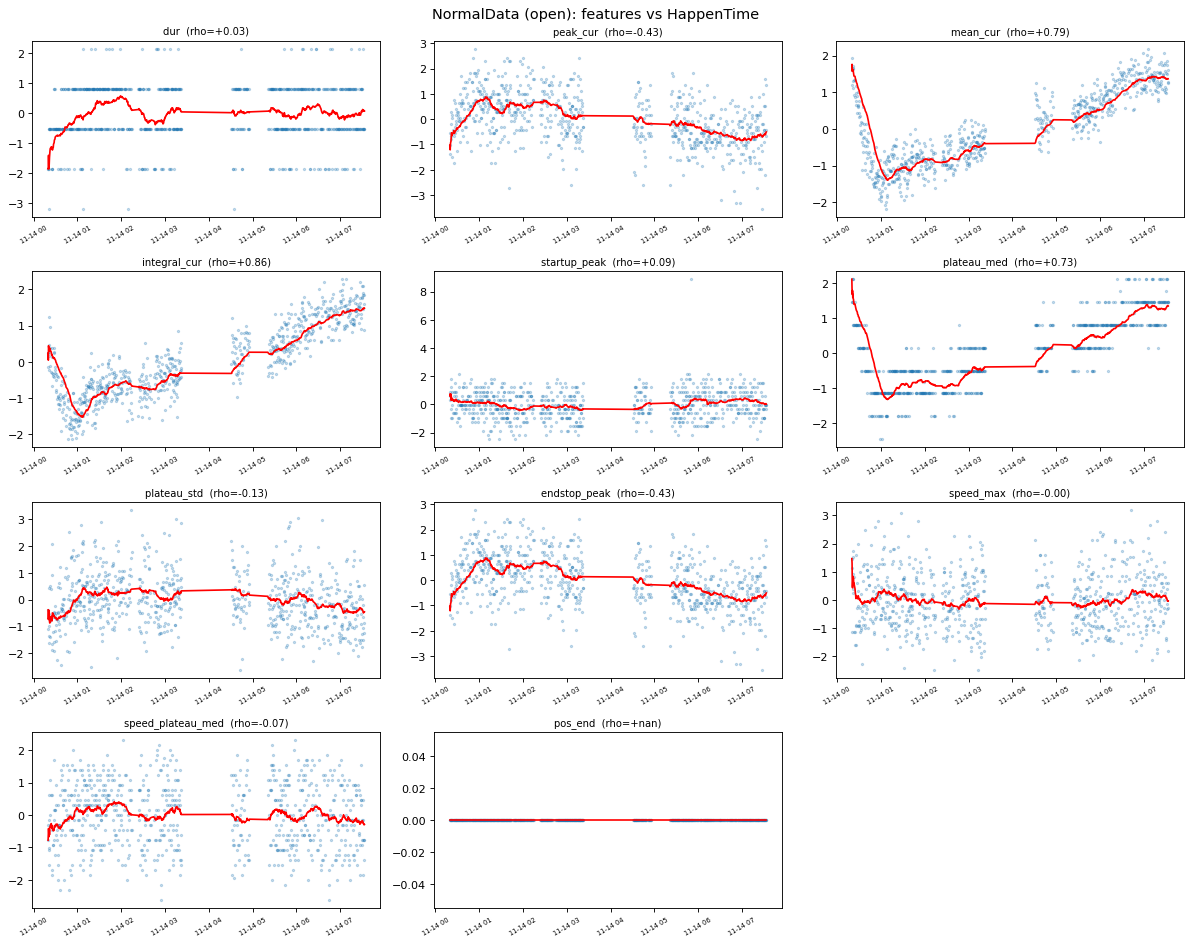

In [66]:
import matplotlib.pyplot as plt

features = ['dur', 'peak_cur', 'mean_cur', 'integral_cur', 'startup_peak',
            'plateau_med', 'plateau_std', 'endstop_peak', 'speed_max',
            'speed_plateau_med', 'pos_end']

# normal cycles only, ordered in time
nd = open_drift[open_drift['label'] == 'NormalData'].sort_values('HappenTime') 

# check and rank the correlation of the features with respect to timestamp (see if it is time dependent)
drift = nd[features].corrwith(nd['HappenTime']).sort_values(key=np.abs, ascending=False) 
print(drift.round(3))

open_drift_large_values = drift[abs(drift)>0.3] # store the variables with large correlations with time for later

# plot each feature against time, with a rolling mean to show any trend
t = pd.to_datetime(nd['HappenTime'], unit='ms')   

fig, axes = plt.subplots(4, 3, figsize=(15, 12))
for ax, f in zip(axes.ravel(), features):
    ax.scatter(t, nd[f], s=4, alpha=0.25)
    ax.plot(t, nd[f].rolling(50, min_periods=1).mean(), color='red', lw=1.5)
    ax.set_title(f'{f}  (rho={drift[f]:+.2f})', fontsize=9)
    ax.tick_params(axis='x', rotation=30, labelsize=6)
for ax in axes.ravel()[len(features):]:
    ax.axis('off')
fig.suptitle('NormalData (open): features vs HappenTime', fontsize=13)
fig.tight_layout()
plt.show()

Three features drift strongly: integral_cur at 0.86, mean_cur at 0.80, and plateau_med at 0.73. All are positive, so the steady current of a healthy open cycle rises over the collection period of 7 hours. Everything other waveform feature has low magnitude, which means little to no trend. 

This is normal-only data, so the sensor is reading a healthy door operation with higher steady current later in the day. A model that keys on the absolute value of those three features could misjudge a cycle based on when it was recorded rather than how the door behaved.

plateau_med         -0.669
pos_end             -0.471
mean_cur            -0.367
peak_cur            -0.339
speed_max            0.230
dur                  0.190
plateau_std          0.157
endstop_peak        -0.144
integral_cur         0.106
speed_plateau_med   -0.101
startup_peak        -0.005
dtype: float64


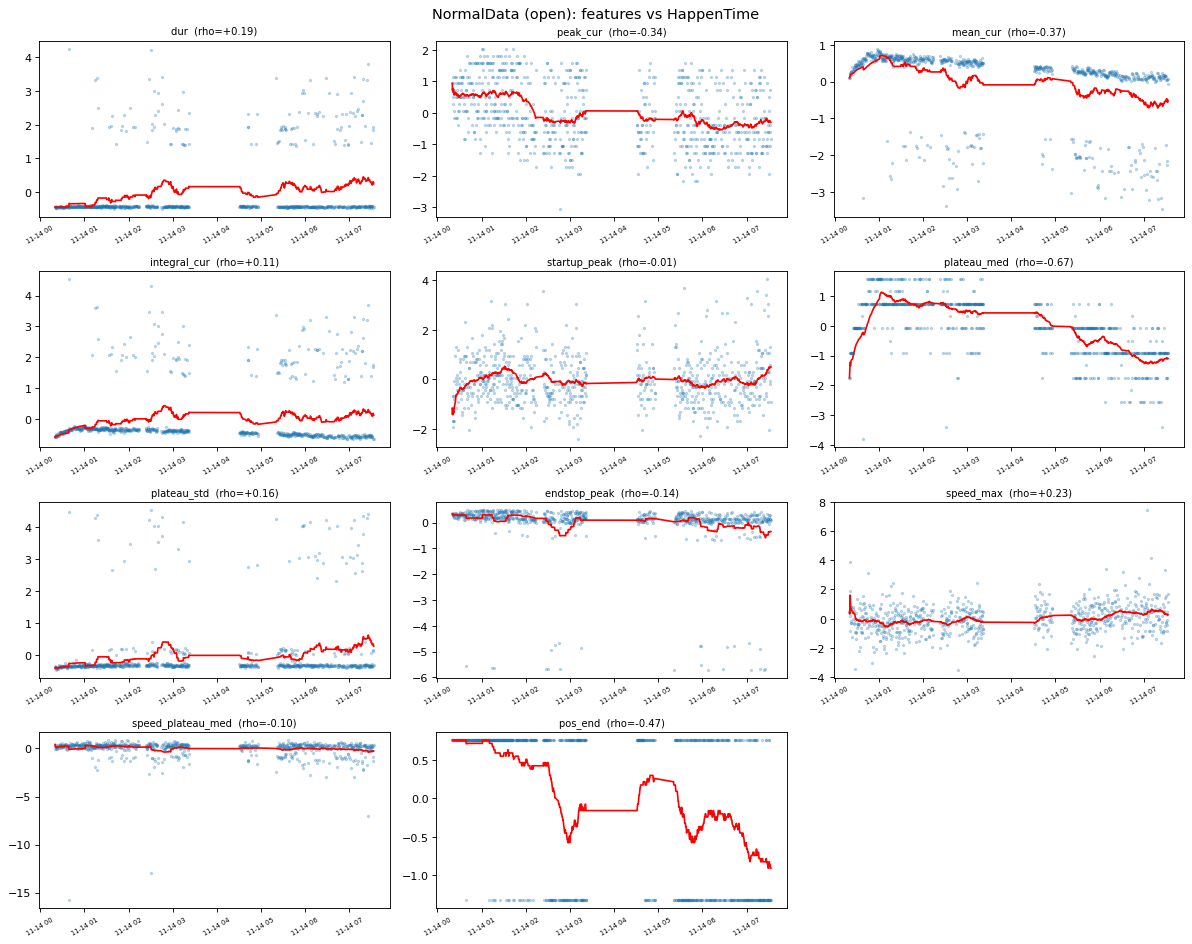

In [67]:
import matplotlib.pyplot as plt

features = ['dur', 'peak_cur', 'mean_cur', 'integral_cur', 'startup_peak',
            'plateau_med', 'plateau_std', 'endstop_peak', 'speed_max',
            'speed_plateau_med', 'pos_end']

# check and rank the correlation of the features with respect to timestamp (see if it is time dependent)
nd = close_drift[close_drift['label'] == 'NormalData'].sort_values('HappenTime') 

# rank-based correlation of each feature with time (robust to the large time gap)
drift = nd[features].corrwith(nd['HappenTime']).sort_values(key=np.abs, ascending=False)
print(drift.round(3))

close_drift_large_values = drift[abs(drift)>0.3] # store the variables with large correlations with time for later


# plot each feature against time, with a rolling mean to show any trend
t = pd.to_datetime(nd['HappenTime'], unit='ms')   

fig, axes = plt.subplots(4, 3, figsize=(15, 12))
for ax, f in zip(axes.ravel(), features):
    ax.scatter(t, nd[f], s=4, alpha=0.25)
    ax.plot(t, nd[f].rolling(50, min_periods=1).mean(), color='red', lw=1.5)
    ax.set_title(f'{f}  (rho={drift[f]:+.2f})', fontsize=9)
    ax.tick_params(axis='x', rotation=30, labelsize=6)
for ax in axes.ravel()[len(features):]:
    ax.axis('off')
fig.suptitle('NormalData (open): features vs HappenTime', fontsize=13)
fig.tight_layout()
plt.show()

For the close cycle the drift is weaker and runs the other way. plateau_med drifts most at -0.67, followed by pos_end at -0.47, mean_cur at -0.37, and peak_cur at -0.34. The signs are negative, so the steady current of a healthy close cycle falls over the collection period, the opposite of the open direction, and the trend is more spread across features rather than concentrated in the three current measures. Every remaining feature has low magnitude and shows little to no trend.

This is normal-only data, so a healthy door is reading lower steady current later in the day, and its end position (pos_end) also shifts over time. As with the open direction, a model that keys on the absolute value of these features could misjudge a cycle based on when it was recorded rather than how the door behaved.

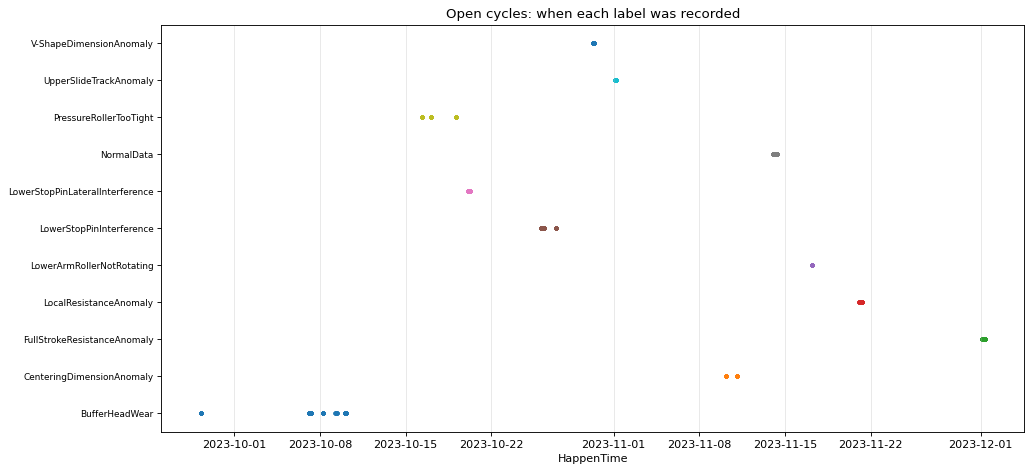

In [68]:
import matplotlib.pyplot as plt

t = pd.to_datetime(df_door_open[df_door_open['HappenTime']>1.69e12]['HappenTime'], unit='ms')   # epoch ms -> datetime
labels = sorted(df_door_open[df_door_open['HappenTime']>1.69e12]['label'].unique())
ypos = {lab: i for i, lab in enumerate(labels)}

fig, ax = plt.subplots(figsize=(13, 6))
for lab in labels:
    m = df_door_open[df_door_open['HappenTime']>1.69e12]['label'] == lab
    ax.scatter(t[m], [ypos[lab]] * m.sum(), s=8, alpha=0.4)
ax.set_yticks(range(len(labels)))
ax.set_yticklabels(labels, fontsize=8)
ax.set_xlabel('HappenTime')
ax.set_title('Open cycles: when each label was recorded')
ax.grid(axis='x', alpha=0.3)
fig.tight_layout(); plt.show()

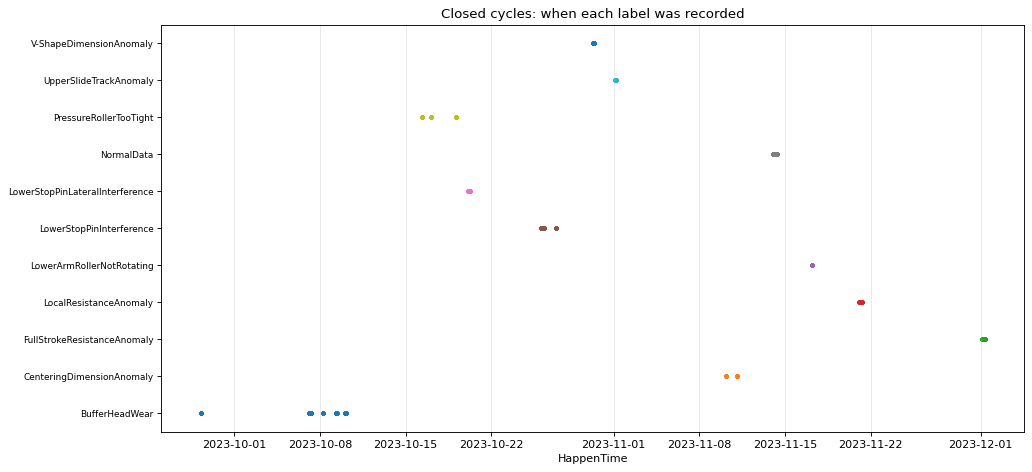

In [69]:
import matplotlib.pyplot as plt

t = pd.to_datetime(df_door_closed[df_door_closed['HappenTime']>1.69e12]['HappenTime'], unit='ms')   # epoch ms -> datetime
labels = sorted(df_door_closed[df_door_closed['HappenTime']>1.69e12]['label'].unique())
ypos = {lab: i for i, lab in enumerate(labels)}

fig, ax = plt.subplots(figsize=(13, 6))
for lab in labels:
    m = df_door_closed[df_door_closed['HappenTime']>1.69e12]['label'] == lab
    ax.scatter(t[m], [ypos[lab]] * m.sum(), s=8, alpha=0.4)
ax.set_yticks(range(len(labels)))
ax.set_yticklabels(labels, fontsize=8)
ax.set_xlabel('HappenTime')
ax.set_title('Closed cycles: when each label was recorded')
ax.grid(axis='x', alpha=0.3)
fig.tight_layout(); plt.show()

It looks like the fault collection data is heavily confounded with HappenTime, so if there is sensor drift over time this could lead to the model capturing changes over time rather than the actual features of the door operations. Therefore the reported model metrics may be optimistic and a production system would require normal and fault cycles gathered over overlapping periods so as to not make HappenTime a confounding factor. 

After the model is trained, we will run a feature importance to see if the features drifting in time come up the most important, and if so that is an important thing to flag out.

## How the approach handles the data challenges

- **Complex file formats:** parsed the nested folder-and-JSON structure into one labelled table, separating scalar, waveform, and digital fields.
- **Irregular sampling and variable length:** reduced each row of data with variable lengths of wave array data to a fixed set of per-cycle features, and resampled waveforms onto a common grid for shape comparison, so cycles of different lengths are directly comparable.
- **Noise and outliers:** Observed the distributions and checked for evidence to determine if data is an outlier or corrupt rather than a true abnormal faulty signal. Also removed isolated sensor spikes with a robust local filter, and used median-based features that are insensitive to residual spikes.
- **Sensor drift:** checked feature stability over time on normal cycles, found and reported drift in the steady-current features, and flagged confounding of certain wave features with HappenTime. The modelling section also discusses building an alternative model that does not use data that is too correlated with HappenTime.

## Anomaly detection

With each cycle now described by a set of numbers, we train a
model to recognise the pattern of each fault. For every new cycle it returns the most
likely diagnosis and a confidence/probability for each fault type, so a maintenance team can see
not just the top answer but how sure the model is.

A Multiclass Random Forest Classifier is chosen as it handles imbalances reasonably well when combined with balanced class weights, and is very interpretable through Feature Importance. It will predict data labels based on the 11 that are already present in the training data. However, if a 12th type of data which is an anomaly not found in the training set were to occur, the model would not be able to flag such an issue. Therefore, for cases like that a binary classifier (Normal or Not Normal) could be more technically accurate. However, in this case we will assume that we are trying to identify 11 possible labels - 1 normal and 10 anomalous.

In [70]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, f1_score


# Train and evaluate a RandomForest for each open and close case, return model + probabilities.
def build_rf(df, name, drop_cols):
    feature_cols = [c for c in df.select_dtypes(include=np.number).columns if c not in drop_cols]
    X, y = df[feature_cols], df["label"]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.25, random_state=42, stratify=y # keep the same proportion of labels as the counts are imbalanced
    )  # withhold 25% of the data for testing of the model to avoid overfitting

    rf = RandomForestClassifier(n_estimators=200, class_weight="balanced",
                                random_state=42, n_jobs=-1)
    rf.fit(X_train, y_train)

    train_f1 = f1_score(y_train, rf.predict(X_train), average="macro")
    test_f1  = f1_score(y_test,  rf.predict(X_test),  average="macro")
    macro = classification_report(y_test, rf.predict(X_test), output_dict=True, zero_division=0)["macro avg"]

    # operational per-label probabilities to show the likelihood of certain faults over others
    proba_df = pd.DataFrame(rf.predict_proba(X_test), columns=rf.classes_, index=X_test.index).round(3)
    report = classification_report(y_test, rf.predict(X_test), output_dict=True, zero_division=0)

    return {"model": rf, "features": feature_cols, "X_test": X_test, "y_test": y_test,
            "y_pred": rf.predict(X_test), "proba": proba_df,
            "train_f1": train_f1, "test_f1": test_f1, "macro": macro,
            "report": report}


common_drop = {"label", "HappenTime", "isopendoor"} # these are target variables, constants or timestamps
open_res  = build_rf(feat_eng_open_scaled,  "OPEN",  common_drop)
close_res = build_rf(feat_eng_close_scaled, "CLOSE", common_drop | {"MaxCurrent"}) # remove MaxCurrent as it is 100% associated with the peak_cur column


rows = []
# produce the model metric numbers
for nm, res in [("OPEN", open_res), ("CLOSE", close_res)]:
    m = res["macro"]
    rows.append({"model": nm,
                 "train_f1": round(res["train_f1"], 3),
                 "test_f1":  round(res["test_f1"], 3),
                 "test_precision": round(m["precision"], 3),
                 "test_recall": round(m["recall"], 3)})

summary = pd.DataFrame(rows).set_index("model")
print(summary.to_string())


       train_f1  test_f1  test_precision  test_recall
model                                                
OPEN      1.000    0.917           0.936        0.904
CLOSE     0.999    0.964           0.960        0.969


In [71]:
def per_label_f1(res):
    rep = res["report"]
    labels = [k for k in rep if k not in ("accuracy", "macro avg", "weighted avg")]
    return pd.Series({lab: round(rep[lab]["f1-score"], 2) for lab in labels})

f1_table = pd.DataFrame({"OPEN": per_label_f1(open_res),
                         "CLOSE": per_label_f1(close_res)}).sort_values("OPEN")
print(f1_table.to_string())

                                 OPEN  CLOSE
LowerArmRollerNotRotating        0.67   0.95
CenteringDimensionAnomaly        0.70   0.90
NormalData                       0.90   0.94
FullStrokeResistanceAnomaly      0.92   0.95
LocalResistanceAnomaly           0.94   0.99
PressureRollerTooTight           0.98   0.94
V-ShapeDimensionAnomaly          0.99   0.99
BufferHeadWear                   0.99   1.00
LowerStopPinLateralInterference  1.00   0.95
LowerStopPinInterference         1.00   1.00
UpperSlideTrackAnomaly           1.00   0.99


How to read precision, recall, and F1:

These three numbers describe how well the model identifies each fault type. All range from 0 (worst) to 1 (best).

**Precision**: Accuracy rate when the model flags a cycle as a given fault. High precision means good predictive accuracy, and since both the test precisions of open and close data are more than 90%, this model is accurate on average, with varying accuracy based on fault type.

**Recall**: Percentage of door cycles that actually had a given fault and were predicted correctly by the model. High recall of 90% or more means this model misses few faults, while a low recall means real faults slip through undetected.

**F1** combines precision and recall into a single score that is high only when both are high. It is the best summary when we care about catching faults and avoiding false alarms at the same time. This is also high for this model.

However, the overall f1 score just shows the average of the accuracy. The accuracy may differ for different fault types, especially since the sample size for some anomalies is small. The F1 score breakdown by fault type shows that for the Door Open dataset, LowerArmROllerNotRotating and CenteringDimensionAnomaly actually have F1 scores 0.7 or below, while for the closed door dataset all faults are above 0.9 F1 score. This means that one has to be cautious when it comes to predicting for certain fault types.

Extracting the probabilities of the labels for each door operation gives users the chance to see what the confidence of the model is, and more easily move on to alternative hypotheses by elimination

In [72]:
def predict_with_proba(model, X):
    """Given a fitted model and a feature DataFrame, return predicted_label plus each label's probability."""
    X = X[model.feature_names_in_]                       # select the model's features, in the right order
    proba = pd.DataFrame(model.predict_proba(X), columns=model.classes_, index=X.index).round(3)
    proba.insert(0, "predicted_label", proba.idxmax(axis=1))
    return proba

# apply to whatever feature set you want to score
open_predictions  = predict_with_proba(open_res["model"],  feat_eng_open_scaled)
close_predictions = predict_with_proba(close_res["model"], feat_eng_close_scaled)

open_predictions.head()

,predicted_label,BufferHeadWear,CenteringDimensionAnomaly,FullStrokeResistanceAnomaly,LocalResistanceAnomaly,LowerArmRollerNotRotating,LowerStopPinInterference,LowerStopPinLateralInterference,NormalData,PressureRollerTooTight,UpperSlideTrackAnomaly,V-ShapeDimensionAnomaly
1,BufferHeadWear,0.870,0.000,0.0,0.0,0.0,0.000,0.000,0.000,0.130,0.000,0.0
3,BufferHeadWear,0.955,0.000,0.0,0.0,0.0,0.000,0.000,0.000,0.045,0.000,0.0
5,BufferHeadWear,0.745,0.005,0.0,0.0,0.0,0.000,0.235,0.000,0.010,0.005,0.0
7,BufferHeadWear,0.970,0.000,0.0,0.0,0.0,0.005,0.000,0.000,0.025,0.000,0.0
9,BufferHeadWear,0.925,0.000,0.0,0.0,0.0,0.000,0.000,0.005,0.070,0.000,0.0


### Feature Importance

=== OPEN ===
integral_cur              0.142
mean_cur                  0.119
LastAngle                 0.104
plateau_med               0.090
peak_cur                  0.067
cur_min                   0.064
plateau_std               0.059
endstop_peak              0.058
MaxCurrent                0.058
dur                       0.050
speed_plateau_med         0.049
pos_end                   0.042
LockSwitchActionAngle     0.041
ActionTime                0.019
CloseSwitchActionAngle    0.014
speed_max                 0.012
startup_peak              0.011
dtype: float64

=== CLOSE ===
cur_min                   0.156
pos_end                   0.119
integral_cur              0.089
plateau_med               0.079
CloseSwitchActionAngle    0.078
mean_cur                  0.077
plateau_std               0.076
startup_peak              0.068
LastAngle                 0.059
dur                       0.051
peak_cur                  0.036
LockSwitchActionAngle     0.034
endstop_peak              0.0

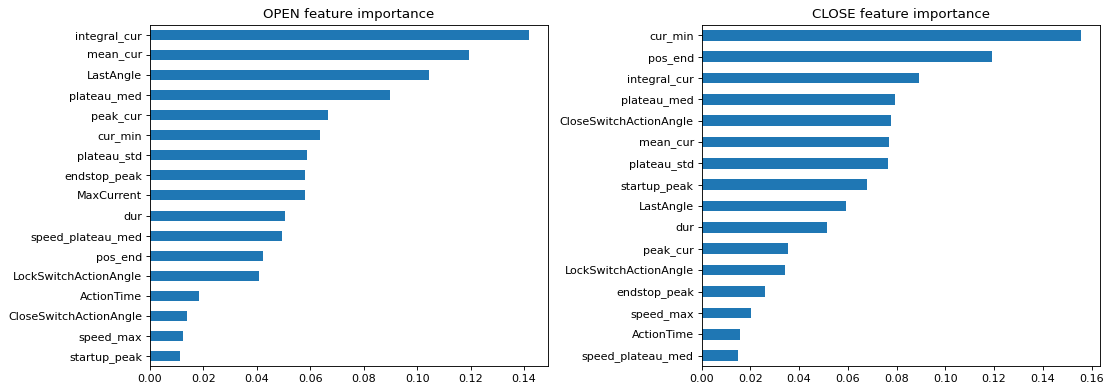

In [73]:
def feature_importance(res):
    """Return the model's feature importances as a sorted Series."""
    return (pd.Series(res["model"].feature_importances_,
                      index=res["model"].feature_names_in_)
              .sort_values(ascending=False))

imp_open  = feature_importance(open_res)
imp_close = feature_importance(close_res)

print("=== OPEN ===")
print(imp_open.round(3))
print("\n=== CLOSE ===")
print(imp_close.round(3))

# optional: plot them
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
imp_open.plot.barh(ax=ax[0], title="OPEN feature importance").invert_yaxis()
imp_close.plot.barh(ax=ax[1], title="CLOSE feature importance").invert_yaxis()
plt.tight_layout()
plt.show()

Remove the large drift features from both datasets and see if the accuracy takes a hit

In [74]:
common_drop = {"label", "HappenTime", "isopendoor"} # these are target variables, constants or timestamps
open_res_withoutdrift  = build_rf(feat_eng_open_scaled,  "OPEN",  common_drop | set(open_drift_large_values.index))
close_res_withoutdrift = build_rf(feat_eng_close_scaled, "CLOSE", common_drop | {"MaxCurrent"} | set(close_drift_large_values.index))


rows = []
# produce the model metric numbers
for nm, res in [("OPEN", open_res_withoutdrift), ("CLOSE", close_res_withoutdrift)]:
    m = res["macro"]
    rows.append({"model": nm,
                 "train_f1": round(res["train_f1"], 3),
                 "test_f1":  round(res["test_f1"], 3),
                 "test_precision": round(m["precision"], 3),
                 "test_recall": round(m["recall"], 3)})

summary = pd.DataFrame(rows).set_index("model")
print(summary.to_string())


       train_f1  test_f1  test_precision  test_recall
model                                                
OPEN      0.999    0.852           0.861        0.846
CLOSE     0.999    0.943           0.949        0.939


Running the model again without the features that were heavily correlated to HappenTime led to some decrease but not extremely significant decreases in accuracy scores. 

Both models stayed strong after removing the time-related features. The open model's f1 score fell 0.07 from 0.92 to 0.85 while the close model fell 0.02 from 0.96 to 0.94. 

The closing model barely changed, so it was already relying on real fault signal. The opening model dropped more, meaning some of its original score came from the time confound, but it still classified faults well without those features.

This means that the models detect genuine fault behaviour, not just the recording time. The opening model's original score was modestly optimistic, so the scores after removing time-related features (0.85 and 0.94) are best read as a cautious lower bound on true performance. The real performance lies between these and the original scores, because some removed features also carried legitimate fault information.



## Conclusion

**Findings:** The sensor data carries a clear signature of door health. After
cleaning the data and summarising each cycle into descriptive features, a classifier
identifies faults with average macro-F1 around 0.92 (open) and 0.95 (close).

**How well it works, by fault:** Certain faults are predicted much more accurately than others, 
probably due to a combination of sample size imbalances, and the impact of different faults on the 
waveform features. Faults that lead to a more significant deviation from the norm (as seen in the visualizations)
are more likely to be identified by the model.

**Caveat:** The biggest caveat is in the data. Normal
and fault cycles were recorded in separate time frames, and some sensor readings may
drift over time, so part of the model's accuracy could reflect recording time rather
than door condition. When we removed the time-affected features, performance dropped
only modestly (open 0.92 to 0.85, close 0.95 to 0.94), which suggests the model is
mostly using genuine fault signal, but the association between some data points and HappenTime
means the overall macro-F1, precision and recall scores should be read as somewhat optimistic.

**Recommendations:** For a production system, collect normal and faulty cycles over
the same time periods to remove the time confound, and gather more examples of the
rare geometry faults. Adding shape-based features that compare a cycle's full current
curve against a normal reference would likely improve detection of the subtle faults.